# Business Understanding

Kemacetan lalu lintas menjadi permasalahan yang terus dihadapi kota-kota besar, termasuk Jakarta, seiring meningkatnya volume kendaraan setiap tahun. Salah satu indikator standar untuk menilai kondisi arus lalu lintas adalah Volume Capacity Ratio (VCRatio), yang menurut Pedoman Kapasitas Jalan Indonesia (PKJI) dikategorikan ke dalam enam tingkat Level of Service (LOS), dari kondisi arus bebas hingga macet total.
Data pencacahan lalu lintas (traffic count) yang direkam otomatis melalui sensor GPS — mencakup volume kendaraan per jenis, kecepatan rata-rata, dan VCRatio dalam interval per jam — menyediakan peluang untuk membangun model klasifikasi yang dapat mengidentifikasi tingkat kepadatan lalu lintas secara otomatis. Ketertarikan untuk mengeksplorasi dataset ini juga didorong oleh karakteristiknya yang cukup kompleks dan realistis: mengandung missing value dengan pola yang beragam, outlier, serta pertanyaan menarik terkait fitur mana yang paling berkontribusi terhadap prediksi — apakah volume kendaraan aktual, atau pola waktu (jam dan hari) yang lebih mudah diketahui di muka dan lebih aplikatif untuk kebutuhan prediksi ke depan.
Melalui analisis ini, dilakukan eksplorasi data secara menyeluruh, proses data cleaning yang disesuaikan dengan karakteristik masing-masing pola missing value, hingga pembangunan model klasifikasi menggunakan pendekatan supervised learning untuk memahami faktor-faktor yang memengaruhi tingkat kepadatan lalu lintas di ruas Jalan Thamrin, Jakarta.

# Import Package

Mempersiapkan semua library yang diperlukan untuk proses analisis, mulai dari pemrosesan data, visualisasi, hingga pembuatan dan evaluasi model machine learning. Selain itu, dilakukan juga pengaturan tampilan grafik dan pengabaian peringatan agar output lebih bersih.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
from matplotlib import rcParams

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn import tree
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score, f1_score, balanced_accuracy_score
from sklearn.metrics import classification_report
from feature_engine.encoding import OneHotEncoder
from feature_engine.encoding import OrdinalEncoder


from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import AdaBoostClassifier
import xgboost as xgb
import catboost as cb

import shap

sns.set_style('darkgrid')
sns.set(font_scale=1.3)

In [2]:
sns.set(rc={'figure.figsize': (20.7,8.27)})
sns.set_style("whitegrid")
sns.color_palette("dark")
plt.style.use("fivethirtyeight")

# Import Dataset

In [3]:
# Read Dataset
df = pd.read_excel('/Users/nabnfikri/Downloads/Dataset/Traffic/traffic_data.xlsx')
data = df
df.sample(5)

,Date_and_Time,In_Motorcycle,In_Car,In_BusTruck,In_Total,In_PCE,In_Velocity,In_VCRatio,Out_Motorcycle,Out_Car,...,Out_PCE,Out_Velocity,Out_VCRatio,Total_Motorcycle,Total_Car,Total_BusTruck,Total_Total,Total_PCE,Total_Velocity,Total_VCRatio
460,2023-01-20 04:00,177.0,140.0,14.0,331.0,202.45,36.898148,0.028497,174.0,134.0,...,195.70,40.908333,0.027547,351.0,274.0,28.0,653.0,398.15,39.008772,0.028022
3606,2023-05-31 06:00,1367.0,731.0,79.0,2177.0,1175.45,24.403509,0.165458,3976.0,1333.0,...,2769.00,18.933333,0.389767,5343.0,2064.0,419.0,7826.0,3944.45,21.598291,0.277612
6436,2023-09-26 04:00,283.0,141.0,41.0,465.0,265.05,41.183333,0.037309,90.0,144.0,...,179.50,47.813725,0.025267,373.0,285.0,51.0,709.0,444.55,44.229730,0.031288
1857,2023-03-19 09:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5348,2023-08-11 20:00,2794.0,1083.0,75.0,3952.0,1879.00,29.716667,0.264490,2341.0,1043.0,...,1715.35,31.950000,0.241454,5135.0,2126.0,142.0,7403.0,3594.35,30.833333,0.252972


# Metadata

# Exploratory Data Analysis

Tahap ini bertujuan untuk memahami distribusi data dan karakteristik variabel yang tersedia. Salah satu langkah awal dalam EDA adalah melihat distribusi variabel target (Total_VCRatio) berdasarkan volume & komposisi kendaraan, waktu, dll. Ini berguna untuk keperluan praktis kayak prediksi kepadatan lalu lintas ke depan. Visualisasi ini membantu dalam mengenali potensi ketidakseimbangan kelas yang dapat mempengaruhi performa model.

## Descriptive Statistics

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Date_and_Time     8760 non-null   str    
 1   In_Motorcycle     8376 non-null   float64
 2   In_Car            8376 non-null   float64
 3   In_BusTruck       8376 non-null   float64
 4   In_Total          8376 non-null   float64
 5   In_PCE            8376 non-null   float64
 6   In_Velocity       8136 non-null   float64
 7   In_VCRatio        8376 non-null   float64
 8   Out_Motorcycle    8479 non-null   float64
 9   Out_Car           8479 non-null   float64
 10  Out_BusTruck      8479 non-null   float64
 11  Out_Total         8479 non-null   float64
 12  Out_PCE           8479 non-null   float64
 13  Out_Velocity      8472 non-null   float64
 14  Out_VCRatio       8479 non-null   float64
 15  Total_Motorcycle  8544 non-null   float64
 16  Total_Car         8544 non-null   float64
 17  Total_

Terdapat missing value dan ada tipe data tidak sesuai di kolom Date_and_Time

In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
In_Motorcycle,8376.0,1618.006566,1119.159800,0.000000,820.000000,1473.000000,2188.000000,8289.000000
In_Car,8376.0,740.491643,426.618775,0.000000,389.000000,751.500000,1061.000000,3495.000000
In_BusTruck,8376.0,70.891714,63.561390,0.000000,31.000000,61.000000,92.000000,1302.000000
In_Total,8376.0,2429.389924,1455.066809,0.000000,1365.000000,2380.000000,3269.000000,9294.000000
In_PCE,8376.0,1237.152513,690.601622,0.000000,689.400000,1266.025000,1720.750000,5111.850000
In_Velocity,8136.0,29.095266,5.892372,1.000000,25.297837,29.923729,32.715517,46.000000
In_VCRatio,8376.0,0.174143,0.097210,0.000000,0.097041,0.178207,0.242215,0.719549
Out_Motorcycle,8479.0,1817.092582,1373.271496,0.000000,857.000000,1582.000000,2426.500000,7536.000000
Out_Car,8479.0,836.394032,494.468152,0.000000,430.000000,858.000000,1103.000000,3729.000000
Out_BusTruck,8479.0,72.354051,64.149778,0.000000,30.000000,60.000000,94.000000,932.000000


## Cek Missing Value

In [6]:
# Jumlah dan persentase missing value per kolom
missing_summary = pd.DataFrame({
    "jumlah_missing": df.isnull().sum(),
    "persentase_missing (%)": (df.isnull().sum() / len(df) * 100).round(2)
})
missing_summary = missing_summary[missing_summary["jumlah_missing"] > 0]
missing_summary.sort_values("persentase_missing (%)", ascending=False)

,jumlah_missing,persentase_missing (%)
In_Velocity,624,7.12
In_Motorcycle,384,4.38
In_Car,384,4.38
In_BusTruck,384,4.38
In_Total,384,4.38
In_PCE,384,4.38
In_VCRatio,384,4.38
Out_Velocity,288,3.29
Out_VCRatio,281,3.21
Out_PCE,281,3.21


## Check Duplicate Rows

In [7]:
duplikat = df.duplicated().sum()
pct_duplikat = duplikat / len(df) * 100
print(f"Jumlah baris duplikat : {duplikat:,}")
print(f"Persentase            : {pct_duplikat:.2f}%")
print(f"Status                : {'⚠️ Ada duplikat!' if duplikat > 0 else '✅ Tidak ada duplikat'}")

Jumlah baris duplikat : 0
Persentase            : 0.00%
Status                : ✅ Tidak ada duplikat


## Cek kelengkapan rentang waktu (gap detection)

Ini krusial untuk data time-series kayak traffic count — perlu tau apakah datanya kontinu per jam tanpa bolong

In [8]:
# mengganti tipe data kolom Date_and_Time
df['Date_and_Time'] = pd.to_datetime(df['Date_and_Time'])

In [9]:
# cek rentang tanggal keseluruhan
print(f"Awal: {df['Date_and_Time'].min()}")
print(f"Akhir: {df['Date_and_Time'].max()}")

# bikin rentang waktu lengkap yang seharusnya ada (per jam)
full_range = pd.date_range(start=df['Date_and_Time'].min(), 
                             end=df['Date_and_Time'].max(), 
                             freq='h')

print(f"Jumlah timestamp seharusnya: {len(full_range)}")
print(f"Jumlah timestamp aktual: {df['Date_and_Time'].nunique()}")

# cari jam-jam yang hilang/bolong
missing_times = full_range.difference(df['Date_and_Time'])
print(f"Jumlah jam yang bolong: {len(missing_times)}")
missing_times[:20]  # intip beberapa contoh

Awal: 2023-01-01 00:00:00
Akhir: 2023-12-31 23:00:00
Jumlah timestamp seharusnya: 8760
Jumlah timestamp aktual: 8760
Jumlah jam yang bolong: 0


DatetimeIndex([], dtype='datetime64[us]', freq='h')

## Investigasi pola missing value (kenapa In_Velocity beda dari kolom In lain?)

In [10]:
# baris di mana In_Motorcycle ada isi tapi In_Velocity kosong
anomali_velocity = df[df['In_Motorcycle'].notna() & df['In_Velocity'].isna()]
print(f"Jumlah baris dengan volume ada tapi velocity kosong: {len(anomali_velocity)}")
anomali_velocity[['Date_and_Time', 'In_Motorcycle', 'In_Car', 'In_BusTruck', 'In_Total', 'In_Velocity']].head(10)

Jumlah baris dengan volume ada tapi velocity kosong: 240


,Date_and_Time,In_Motorcycle,In_Car,In_BusTruck,In_Total,In_Velocity
1,2023-01-01 01:00:00,0.0,0.0,0.0,0.0,NaN
2,2023-01-01 02:00:00,0.0,0.0,0.0,0.0,NaN
3,2023-01-01 03:00:00,0.0,0.0,0.0,0.0,NaN
29,2023-01-02 05:00:00,0.0,0.0,0.0,0.0,NaN
76,2023-01-04 04:00:00,0.0,0.0,0.0,0.0,NaN
77,2023-01-04 05:00:00,0.0,0.0,0.0,0.0,NaN
78,2023-01-04 06:00:00,0.0,0.0,0.0,0.0,NaN
84,2023-01-04 12:00:00,0.0,0.0,0.0,0.0,NaN
94,2023-01-04 22:00:00,0.0,0.0,0.0,0.0,NaN
95,2023-01-04 23:00:00,0.0,0.0,0.0,0.0,NaN


Semua 240 baris punya pola yang sama: In_Motorcycle, In_Car, In_BusTruck, In_Total = 0, dan In_Velocity = NaN (bukan 0).

Ini logis secara domain: kalau gak ada kendaraan sama sekali yang lewat (In_Total = 0), maka gak ada kecepatan yang bisa diukur — gak ada data buat dihitung rata-ratanya. Jadi sensor mencatat NaN untuk velocity karena memang secara matematis undefined (mirip kayak coba hitung rata-rata dari himpunan kosong), bukan karena sensor rusak.

In [11]:
# baris di mana SEMUA kolom In kosong (bukan 0, tapi NaN)
semua_in_kosong = df[df['In_Motorcycle'].isna()]
print(f"Jumlah baris semua In kosong (NaN): {len(semua_in_kosong)}")
semua_in_kosong[['Date_and_Time', 'In_Motorcycle', 'In_Car', 'In_Total', 'In_Velocity']].head(10)

Jumlah baris semua In kosong (NaN): 384


,Date_and_Time,In_Motorcycle,In_Car,In_Total,In_Velocity
6,2023-01-01 06:00:00,NaN,NaN,NaN,NaN
7,2023-01-01 07:00:00,NaN,NaN,NaN,NaN
8,2023-01-01 08:00:00,NaN,NaN,NaN,NaN
9,2023-01-01 09:00:00,NaN,NaN,NaN,NaN
11,2023-01-01 11:00:00,NaN,NaN,NaN,NaN
12,2023-01-01 12:00:00,NaN,NaN,NaN,NaN
13,2023-01-01 13:00:00,NaN,NaN,NaN,NaN
92,2023-01-04 20:00:00,NaN,NaN,NaN,NaN
93,2023-01-04 21:00:00,NaN,NaN,NaN,NaN
103,2023-01-05 07:00:00,NaN,NaN,NaN,NaN


Di sini semua kolom (In_Motorcycle, In_Car, In_Total, In_Velocity) kosong total (NaN), bukan 0.0. Ini kemungkinan besar sensor arah masuk benar-benar gak mencatat apapun di jam-jam tersebut (bukan "0 kendaraan lewat", tapi "gak ada data sama sekali").

In [12]:
# Perlu dicek pola waktunya — apakah acak atau berpola (Ini penting untuk nentuin strategi cleaning nanti)
semua_in_kosong = df[df['In_Motorcycle'].isna()].copy()
semua_in_kosong['jam'] = semua_in_kosong['Date_and_Time'].dt.hour
semua_in_kosong['bulan'] = semua_in_kosong['Date_and_Time'].dt.month

# cek distribusi per jam - apakah sensor mati di jam tertentu aja?
print("Distribusi per jam:")
print(semua_in_kosong['jam'].value_counts().sort_index())

print("\nDistribusi per bulan:")
print(semua_in_kosong['bulan'].value_counts().sort_index())

Distribusi per jam:
jam
0     12
1      8
2      6
3      7
4      6
5      7
6     59
7     59
8     58
9     59
10     6
11    11
12    13
13     6
14     3
15     2
16     6
17     8
18     6
19     9
20     6
21     8
22     8
23    11
Name: count, dtype: int64

Distribusi per bulan:
bulan
1     38
2     42
3     23
4     69
5     32
6     29
7     35
8     18
9     21
10    22
11    30
12    25
Name: count, dtype: int64


Insight utama

1. Konsentrasi tajam di jam 06:00-09:00
Jam 6, 7, 8, 9 masing-masing punya ~59 baris kosong — jauh di atas jam-jam lain yang cuma single digit (rata-rata 6-13 baris). Total dari 4 jam ini aja: 235 dari 384 baris (61%). Ini bukan kebetulan — kemungkinan besar ada penyebab sistematis, seperti:

Maintenance rutin sensor/alat pencacah di jam pagi tersebut
Pergantian shift petugas (kalau ini pencacahan manual, bukan sensor otomatis)
Downtime terjadwal sistem di jam tertentu

2. Distribusi bulan relatif merata, dengan April (bulan 4) sedikit menonjol (69 baris) — tapi gak sedominan pola per jam di atas. Ini kemungkinan cuma variasi normal, bukan pola sistematis yang perlu dicurigai khusus.

In [13]:
# cek apakah missing-nya berurutan (blok) atau random tersebar
semua_in_kosong_sorted = semua_in_kosong.sort_values('Date_and_Time')
semua_in_kosong_sorted['selisih_jam'] = semua_in_kosong_sorted['Date_and_Time'].diff().dt.total_seconds() / 3600

# hitung berapa "blok" downtime yang berurutan (selisih 1 jam = berurutan)
print(f"Jumlah baris dengan selisih 1 jam dari baris sebelumnya (berurutan): {(semua_in_kosong_sorted['selisih_jam'] == 1).sum()}")

Jumlah baris dengan selisih 1 jam dari baris sebelumnya (berurutan): 270


downtime yang terjadi biasanya beberapa jam berturut-turut, bukan cuma 1 jam terisolasi. Ini konsisten dengan temuan poin 1 di atas (misal sensor mati dari jam 6 sampai 9 pagi sekaligus di hari-hari tertentu).

In [14]:
# cek apakah pola jam 6-9 ini terjadi di HARI yang sama berulang, atau tersebar acak antar hari
jam_6_9 = semua_in_kosong[semua_in_kosong['jam'].isin([6,7,8,9])].copy()
jam_6_9['tanggal'] = jam_6_9['Date_and_Time'].dt.date
print(f"Jumlah hari unik yang kena downtime jam 6-9: {jam_6_9['tanggal'].nunique()}")
print(jam_6_9['tanggal'].value_counts().head(20))

Jumlah hari unik yang kena downtime jam 6-9: 64
tanggal
2023-01-01    4
2023-01-08    4
2023-01-15    4
2023-01-22    4
2023-01-29    4
2023-02-05    4
2023-02-12    4
2023-02-19    4
2023-02-26    4
2023-03-05    4
2023-03-12    4
2023-03-19    4
2023-03-26    4
2023-04-02    4
2023-04-04    4
2023-04-09    4
2023-04-16    4
2023-04-23    4
2023-04-30    4
2023-05-07    4
Name: count, dtype: int64


Polanya jelas: setiap hari Minggu, jam 06:00-09:00, sensor arah masuk mati/gak mencatat. Ini sangat konsisten — 63 dari 64 hari yang kena adalah hari Minggu, cuma 1 anomali (04 April, hari Selasa) yang menyimpang dari pola.

Interpretasi

Ini hampir pasti downtime terjadwal/maintenance rutin mingguan, kemungkinan karena:

Petugas melakukan kalibrasi/perawatan sensor tiap Minggu pagi (mungkin dipilih Minggu karena jam segitu emang biasanya sepi, jadi "waktu aman" buat maintenance)
Sistem restart otomatis mingguan yang terjadwal
Shift petugas pencatatan manual libur di hari Minggu pagi tersebut

## Cek konsistensi logis: apakah Total = In + Out?

In [15]:
# toleransi kecil untuk floating point, misal 0.01
cek_total = df[abs((df['In_Total'] + df['Out_Total']) - df['Total_Total']) > 0.01]
print(f"Jumlah baris yang Total-nya TIDAK konsisten dengan In+Out: {len(cek_total)}")
cek_total[['Date_and_Time', 'In_Total', 'Out_Total', 'Total_Total']].head(10)

Jumlah baris yang Total-nya TIDAK konsisten dengan In+Out: 0


,Date_and_Time,In_Total,Out_Total,Total_Total


Total = In + Out konsisten 100% di seluruh data (gak ada kesalahan hitung/anomali di level agregasi). Ini nunjukin data kamu punya integritas struktural yang baik, minimal dari sisi konsistensi antar kolom.

## Cek outlier pakai boxplot

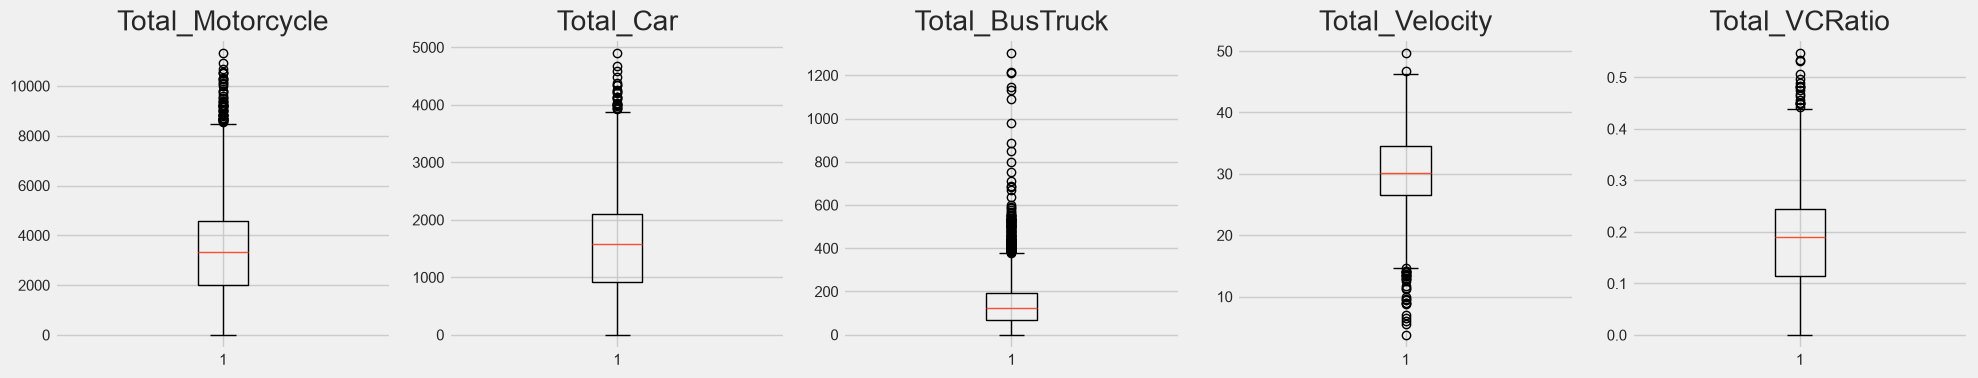

In [16]:
import matplotlib.pyplot as plt

kolom_cek = ['Total_Motorcycle', 'Total_Car', 'Total_BusTruck', 'Total_Velocity', 'Total_VCRatio']

fig, axes = plt.subplots(1, len(kolom_cek), figsize=(20, 4))
for i, col in enumerate(kolom_cek):
    axes[i].boxplot(df[col].dropna())
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

- Total_Motorcycle, Total_Car, Total_BusTruck — semua outlier ada di sisi atas (volume kendaraan tinggi), masuk akal karena kemungkinan itu jam-jam puncak/rush hour yang ekstrem, bukan error
- Total_BusTruck — outlier-nya paling banyak & jaraknya paling jauh dari box (proporsional sih, karena bus/truk emang jarang lewat dalam jumlah banyak dibanding motor/mobil, jadi wajar variasinya lebih "melebar" ke atas)
- Total_Velocity — ini menarik, ada outlier di kedua sisi (atas & bawah) — velocity rendah ekstrem (di bawah 10) bisa jadi indikasi macet parah, sementara velocity tinggi ekstrem (di atas 45) bisa jadi arus benar-benar lengang/kosong
- Total_VCRatio — outlier di atas (mendekati 0.5), yang sebetulnya masih dalam kategori LOS B kalau ngacu ke threshold yang kamu pakai sebelumnya (0.21-0.44 = B), jadi belum tentu ini "ekstrem" secara domain, meskipun secara statistik terdeteksi sebagai outlier

## Cek pola waktu (temporal pattern)

Ini penting sebagai bagian eksplorasi awal sebelum modeling — lihat pola per jam

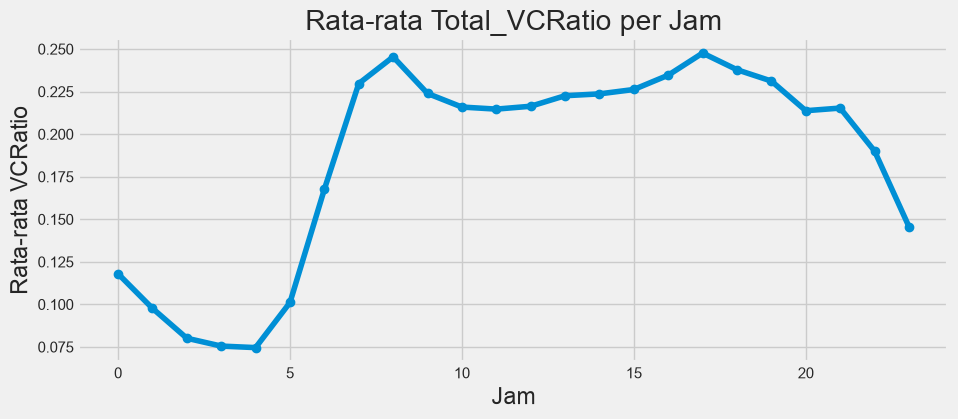

In [17]:
df['hour'] = df['Date_and_Time'].dt.hour
df.groupby('hour')['Total_VCRatio'].mean().plot(kind='line', marker='o', figsize=(10,4))
plt.title('Rata-rata Total_VCRatio per Jam')
plt.xlabel('Jam')
plt.ylabel('Rata-rata VCRatio')
plt.grid(True)
plt.show()

Interpretasi pola
- Jam 0-4 (dini hari): VCRatio paling rendah (~0.075-0.12) — wajar, karena aktivitas lalu lintas paling sepi di jam segini
- Jam 5-8 (pagi): Kenaikan tajam dari ~0.10 ke ~0.24 — ini rush hour pagi, orang mulai berangkat kerja/sekolah, sesuai ekspektasi
- Jam 9-15 (siang): Relatif stabil di kisaran 0.22-0.23 — aktivitas siang hari yang konsisten (kerja, sekolah, aktivitas komersial)
- Jam 16-17 (sore): Puncak tertinggi (~0.245-0.248) — ini rush hour sore/pulang kerja, sesuai dengan pola lalu lintas kota pada umumnya
- Jam 18-23 (malam): Penurunan bertahap sampai titik terendah kedua di jam 23 (~0.145) — orang mulai pulang & beraktivitas berkurang

## Cek distribusi Total_VCRatio (sebelum jadi target)

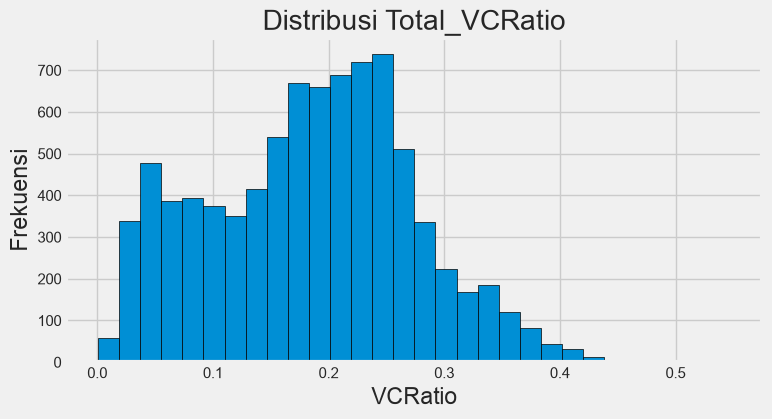

In [18]:
plt.figure(figsize=(8,4))
plt.hist(df['Total_VCRatio'].dropna(), bins=30, edgecolor='black')
plt.title('Distribusi Total_VCRatio')
plt.xlabel('VCRatio')
plt.ylabel('Frekuensi')
plt.show()

## Univariate Analysis

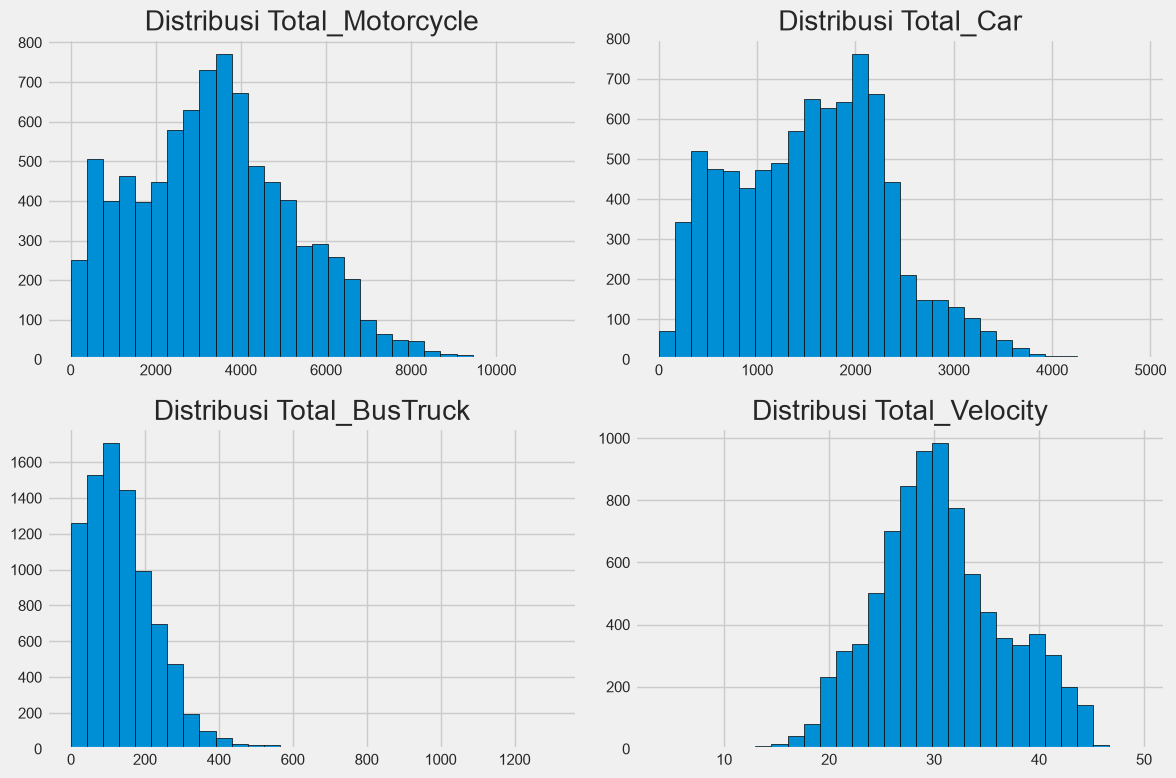

In [19]:
kolom_numerik = ['Total_Motorcycle', 'Total_Car', 'Total_BusTruck', 'Total_Velocity']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for i, col in enumerate(kolom_numerik):
    ax = axes[i//2, i%2]
    ax.hist(df[col].dropna(), bins=30, edgecolor='black')
    ax.set_title(f'Distribusi {col}')
plt.tight_layout()
plt.show()

| Kolom | Bentuk Distribusi | Catatan |
|---|---|---|
| `Total_Motorcycle` | Bimodal, sedikit skewed kanan | Terkait pola rush hour |
| `Total_Car` | Bimodal, sedikit skewed kanan | Terkait pola rush hour |
| `Total_BusTruck` | Sangat skewed kanan | Perlu perhatian khusus (outlier & skewness tertinggi) |
| `Total_Velocity` | Mendekati normal | Paling stabil |
| `Total_VCRatio` | Mendekati normal, sedikit bimodal | Cocok jadi basis target |



<!-- Kolom	Bentuk Distribusi	Catatan
Total_Motorcycle	       Bimodal, sedikit skewed kanan	Terkait pola rush hour
Total_Car	             Bimodal, sedikit skewed kanan	Terkait pola rush hour
Total_BusTruck	Sangat skewed kanan	Perlu perhatian khusus (outlier & skewness tertinggi)
Total_Velocity	Mendekati normal	Paling stabil
Total_VCRatio	Mendekati normal, sedikit bimodal	Cocok jadi basis target -->

## Cek skewness tiap kolom (seberapa miring distribusinya)

In [20]:
df[['Total_Motorcycle', 'Total_Car', 'Total_BusTruck', 'Total_Velocity', 'Total_VCRatio']].skew()

Total_Motorcycle    0.389588
Total_Car           0.254831
Total_BusTruck      1.991776
Total_Velocity      0.133395
Total_VCRatio       0.090249
dtype: float64

| Kolom | Skewness | Interpretasi |
|---|---|---|
| `Total_Motorcycle` | 0.39 | Mendekati simetris, sedikit condong ke kanan (wajar) |
| `Total_Car` | 0.25 | Mendekati simetris, hampir gak ada skew |
| `Total_BusTruck` | **1.99** | Skewed berat ke kanan — konsisten dengan boxplot sebelumnya yang menunjukkan banyak outlier di sisi atas |
| `Total_Velocity` | 0.13 | Sangat simetris, hampir normal |
| `Total_VCRatio` | 0.09 | Sangat simetris, hampir normal (sesuai histogram bimodal-nya yang lumayan seimbang) |

## Bivariate Analysis

### Scatter plot TotalCar vs TotalVCRatio

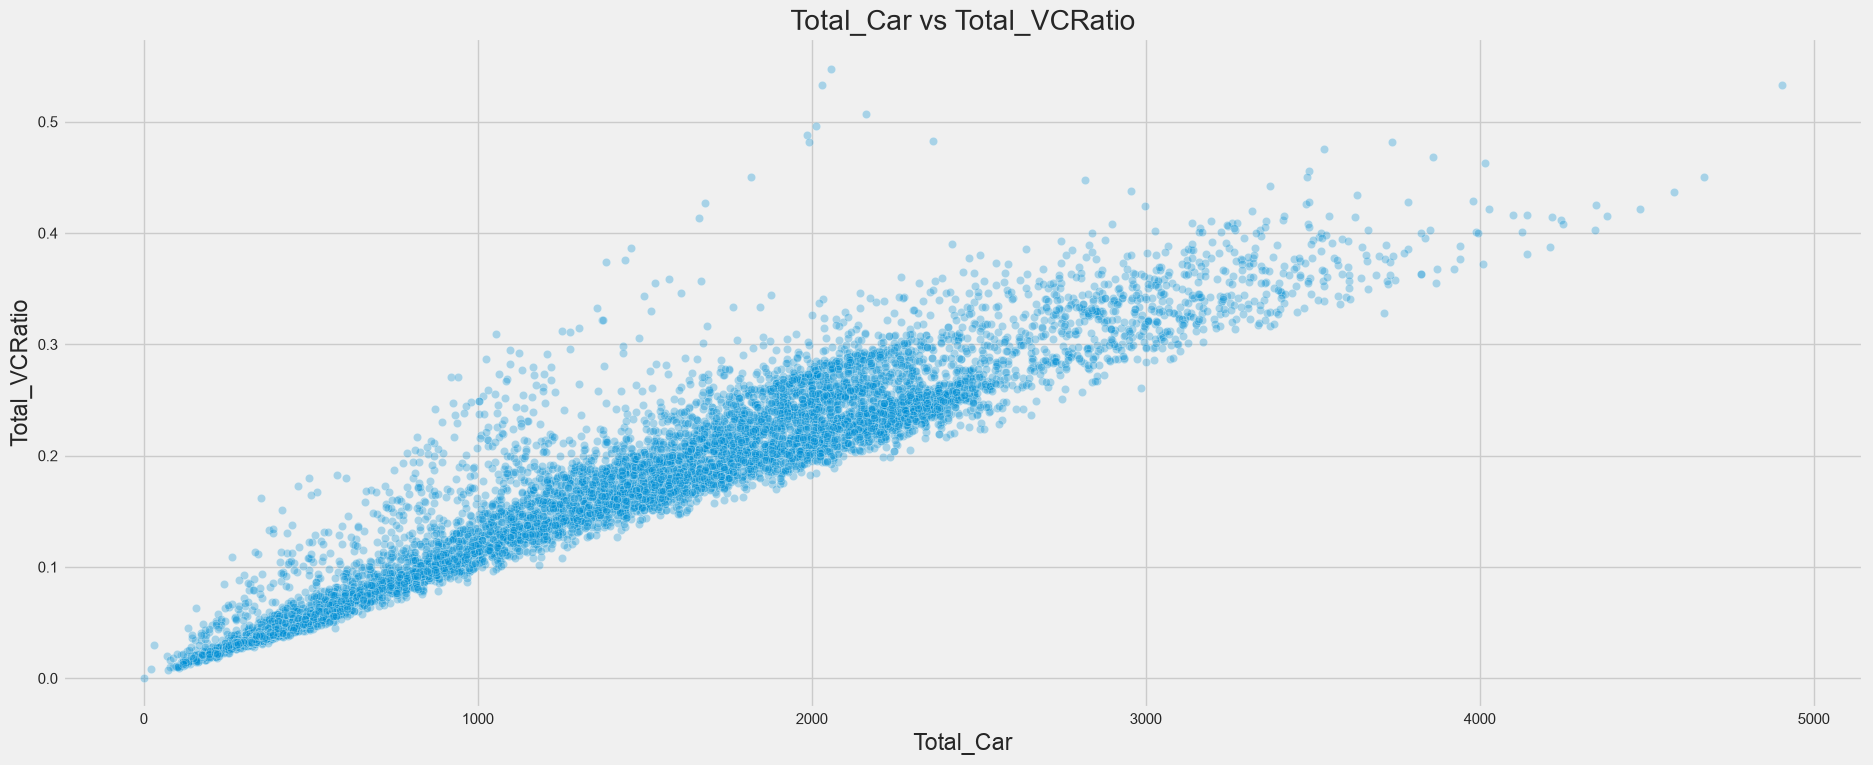

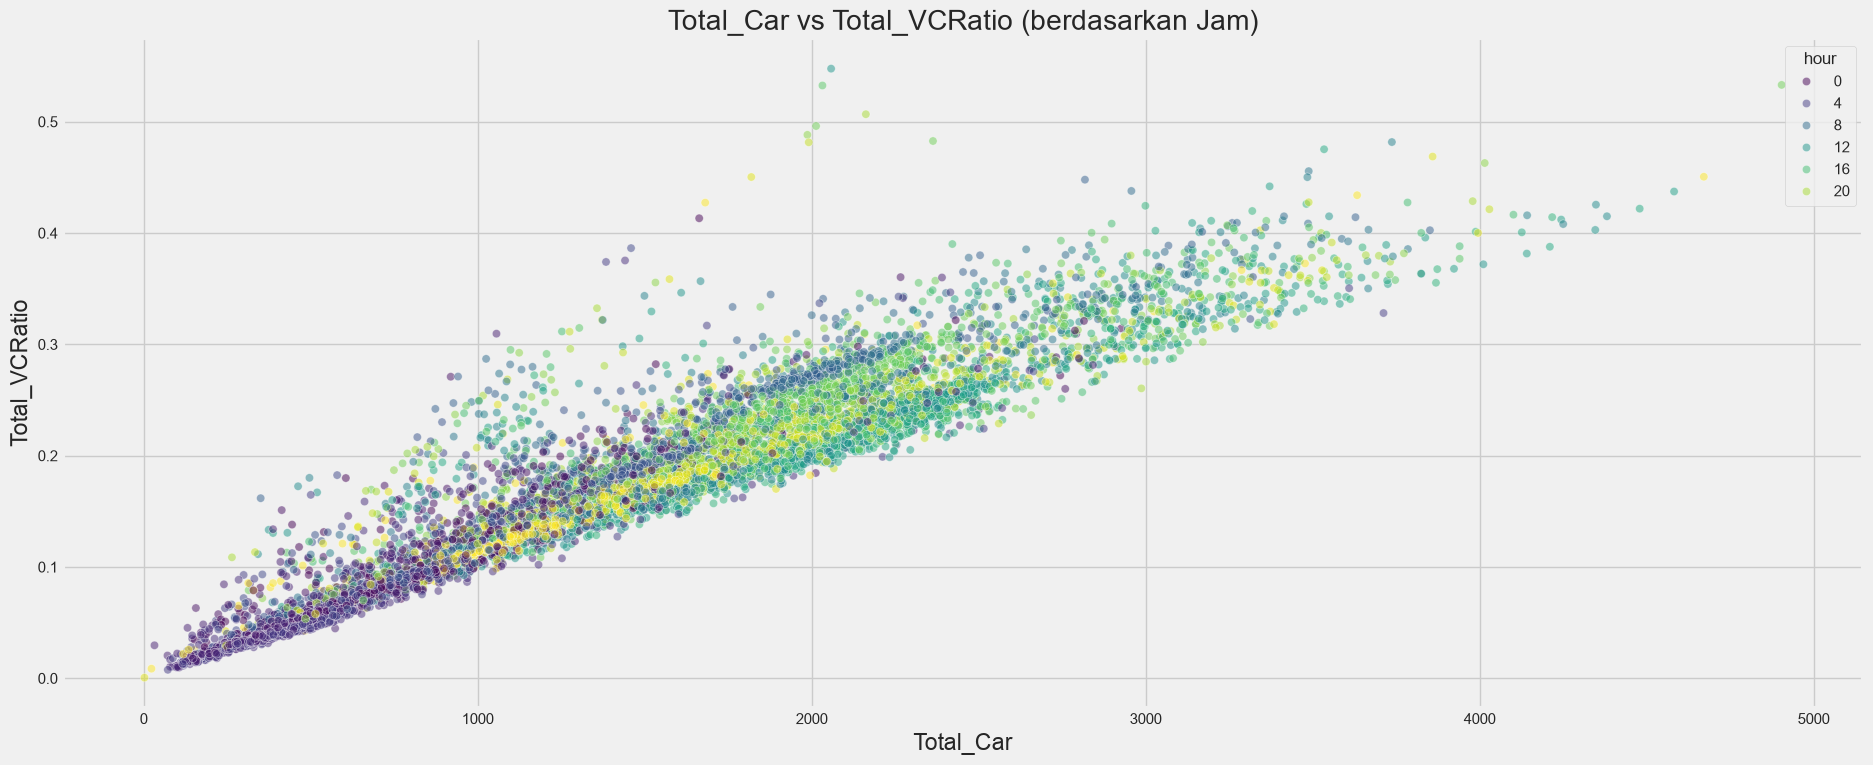

In [21]:
import seaborn as sns

# bivariate biasa
sns.scatterplot(data=df, x='Total_Car', y='Total_VCRatio', alpha=0.3)
plt.title('Total_Car vs Total_VCRatio')
plt.show()

# ini baru multivariate - nambah dimensi ke-3 (misal jam sebagai warna)
sns.scatterplot(data=df, x='Total_Car', y='Total_VCRatio', hue='hour', palette='viridis', alpha=0.5)
plt.title('Total_Car vs Total_VCRatio (berdasarkan Jam)')
plt.show()

- Insight dari plot pertama (bivariate — tanpa hue)

Hubungan linear yang sangat kuat dan konsisten antara Total_Car dan Total_VCRatio — titik-titiknya membentuk garis yang rapat dan hampir lurus, sangat sedikit noise/scatter di luar pola utama. Ini konfirmasi visual dari korelasi 0.94 yang kita lihat sebelumnya.


- Insight dari plot kedua (multivariate — dengan hue jam)

Ini yang lebih menarik — perhatikan gradasi warnanya:
Warna gelap (ungu, jam 0) cenderung mengelompok di bagian bawah-kiri (volume rendah, VCRatio rendah) — jam tengah malam, wajar sepi.
Warna kuning (jam 20/malam) dan hijau muda tersebar lebih ke kanan-atas — volume & VCRatio lebih tinggi

### Scatter plot Velocity vs VCRatio

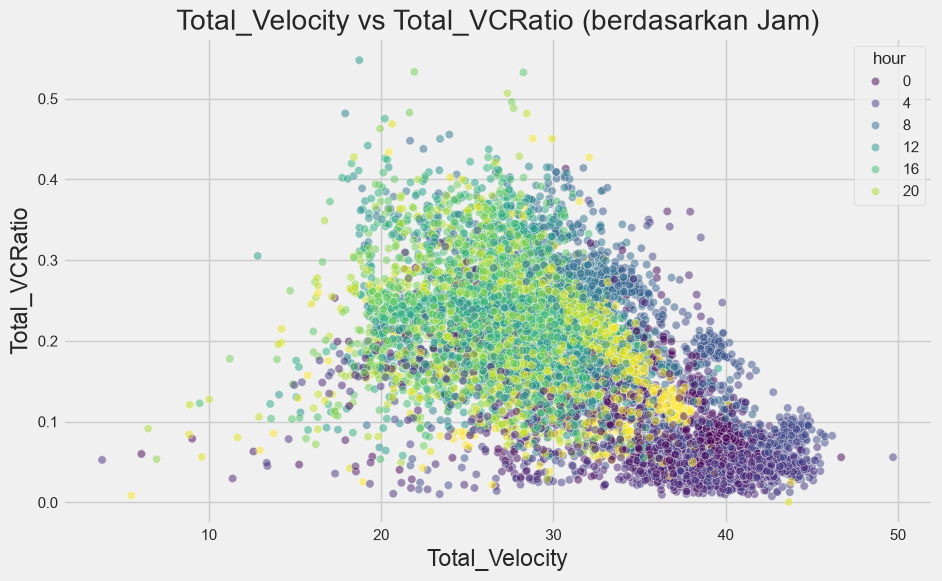

In [22]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Total_Velocity', y='Total_VCRatio', hue='hour', palette='viridis', alpha=0.5)
plt.title('Total_Velocity vs Total_VCRatio (berdasarkan Jam)')
plt.show()

## Multivariate Analysis

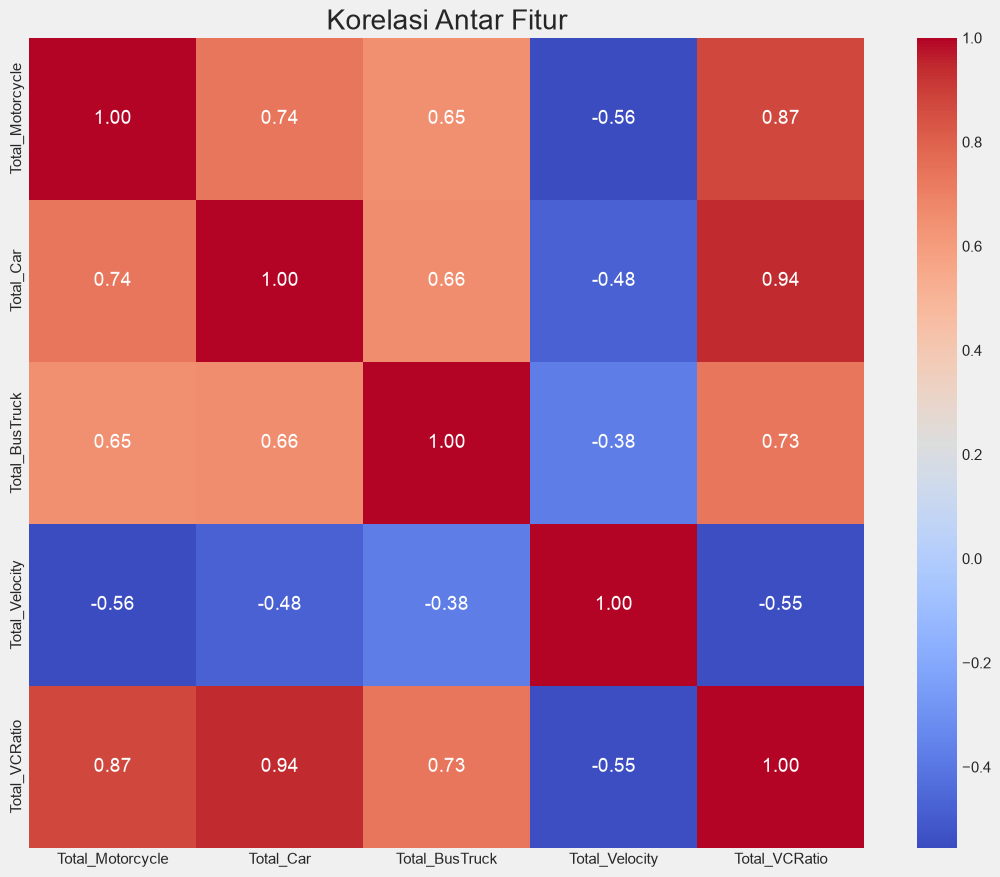

In [23]:
import seaborn as sns

kolom_numerik = ['Total_Motorcycle', 'Total_Car', 'Total_BusTruck', 'Total_Velocity', 'Total_VCRatio']
corr = df[kolom_numerik].corr()

plt.figure(figsize=(12,10))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Korelasi Antar Fitur')
plt.show()

Insight utama

1. Korelasi sangat tinggi antara Total_Car dan Total_VCRatio (0.94)
Ini yang paling menonjol — nyaris korelasi sempurna. Masuk akal secara domain (makin banyak mobil, makin padat), tapi ini red flag penting untuk modeling: kalau kamu pakai Total_Car sebagai fitur buat prediksi target yang diturunkan dari Total_VCRatio, model kamu bisa "curang" — cuma mengandalkan 1 fitur ini buat nebak target dengan akurasi sangat tinggi, tapi itu bukan pembelajaran pola yang bermakna, lebih ke arah proxy/leakage ringan.

2. Total_Motorcycle juga korelasi tinggi dengan Total_VCRatio (0.87)
Sama seperti poin di atas — motor & mobil adalah kontributor volume kendaraan terbesar, jadi wajar mereka paling berkorelasi kuat dengan tingkat kepadatan (VCRatio).

3. Total_Velocity berkorelasi negatif dengan semua fitur volume (-0.38 sampai -0.56)
Ini sangat masuk akal secara domain: makin banyak kendaraan (motor/mobil/bus-truk), makin lambat kecepatan rata-rata. Pola klasik hukum kepadatan-kecepatan lalu lintas — validasi bagus bahwa data kamu konsisten dengan teori transportasi.

4. Antar fitur volume kendaraan (Motorcycle, Car, BusTruck) saling berkorelasi (0.65-0.74)
Ini juga wajar — kalau jam sedang ramai, semua jenis kendaraan cenderung ramai bareng (rush hour mempengaruhi semua jenis kendaraan, bukan cuma satu jenis)

## Analisis Weekday vs Weekend

In [24]:
# Buat kolom penanda weekday/weekend
df['hari'] = df['Date_and_Time'].dt.day_name()
df['is_weekend'] = df['Date_and_Time'].dt.dayofweek >= 5  # Sabtu=5, Minggu=6

In [25]:
# Bandingkan rata-rata VCRatio weekday vs weekend
df.groupby('is_weekend')['Total_VCRatio'].mean()

is_weekend
False    0.186960
True     0.178317
Name: Total_VCRatio, dtype: float64

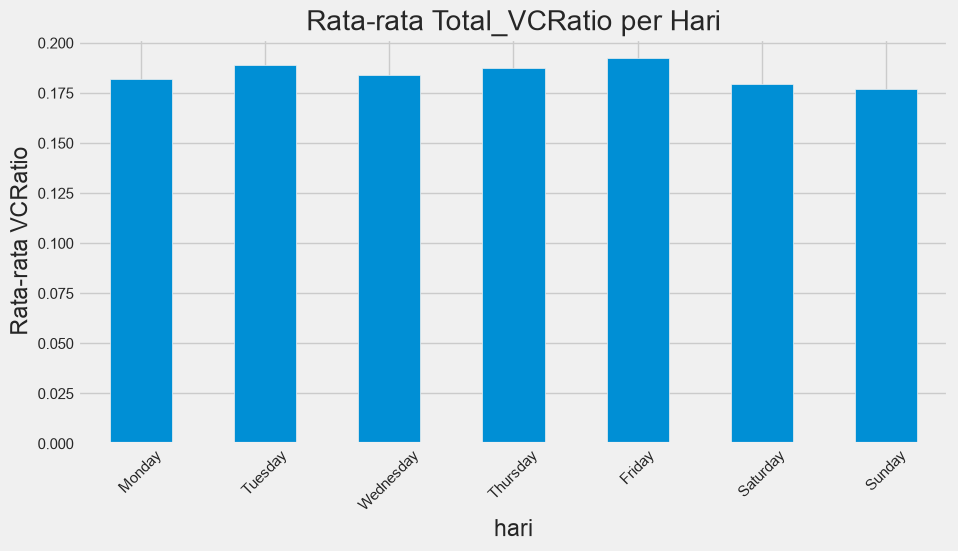

In [26]:
# Visualisasi per hari (lebih detail dari sekadar weekday/weekend)
plt.figure(figsize=(10,5))
df.groupby('hari')['Total_VCRatio'].mean().reindex(
    ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
).plot(kind='bar')
plt.title('Rata-rata Total_VCRatio per Hari')
plt.ylabel('Rata-rata VCRatio')
plt.xticks(rotation=45)
plt.show()

1. Weekday (Senin-Jumat) sedikit lebih tinggi dari weekend
   
Weekday: berkisar 0.182-0.192
Weekend (Sabtu-Minggu): berkisar 0.177-0.179

Bedanya cuma sekitar 0.01-0.015 — ini perbedaan yang relatif kecil, meski arahnya sesuai ekspektasi (hari kerja lebih padat karena aktivitas komuter/bisnis).

2. Jumat adalah hari paling padat (0.192)
Ini juga masuk akal secara domain — Jumat sering jadi hari dengan aktivitas tambahan (kadang orang pulang lebih awal, atau ada aktivitas weekend prep, tergantung konteks kota/wilayah).

3. Minggu adalah hari paling lancar (0.177)
Konsisten dengan temuan kamu sebelumnya soal downtime sensor yang justru sering terjadi hari Minggu pagi — dan makin memperkuat gambaran bahwa Minggu memang hari dengan mobilitas paling rendah.

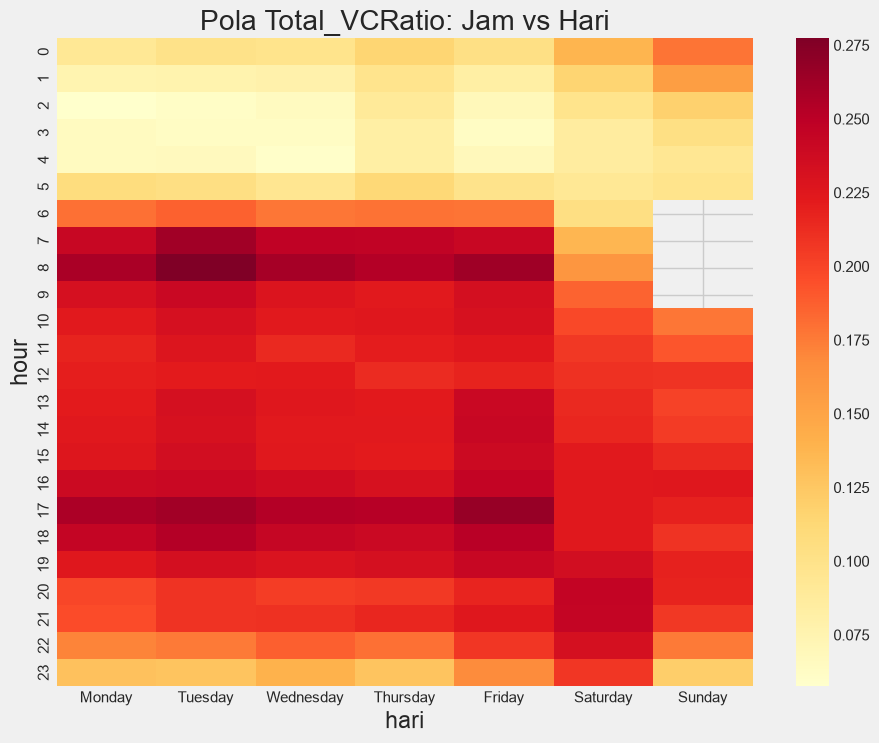

In [27]:
# Kombinasi jam & weekday/weekend (heatmap pola mingguan)
pivot = df.pivot_table(values='Total_VCRatio', index='hour', columns='hari', aggfunc='mean')
pivot = pivot[['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']]

plt.figure(figsize=(10,8))
sns.heatmap(pivot, cmap='YlOrRd', annot=False)
plt.title('Pola Total_VCRatio: Jam vs Hari')
plt.show()

# Preproccesing Sebelum Split Data

## Handling Missing Value In_Velocity

In [28]:
df['In_Velocity'] = df.apply(lambda row: 0 if row['In_Total']==0 and pd.isna(row['In_Velocity']) else row['In_Velocity'], axis=1)

## Tambah Fitur hour dan day_name

In [29]:
df['hour'] = df['Date_and_Time'].dt.hour
df['hari'] = df['Date_and_Time'].dt.day_name()

## Membuat Kolom Target kategori_lalin

In [30]:
def kategori_lalin(vc):
    if pd.isna(vc):
        return None
    return 'Lancar' if vc <= 0.20 else 'Cukup Padat'

df['kategori_lalin'] = df['Total_VCRatio'].apply(kategori_lalin)

# drop baris yang target-nya masih NaN (216 baris tadi) SEBELUM split
df_model = df.dropna(subset=['kategori_lalin']).copy()

## Cek dulu pola missing value di Out_Total

In [31]:
missing_out = df_model[df_model['Out_Total'].isna()]

print(f"Jumlah baris Out_Total kosong: {len(missing_out)}")
print("\nDistribusi per jam:")
print(missing_out['hour'].value_counts().sort_index())

print("\nDistribusi per hari:")
print(missing_out['hari'].value_counts())

Jumlah baris Out_Total kosong: 65

Distribusi per jam:
hour
0     2
1     1
2     2
3     4
4     3
5     3
6     2
7     2
8     2
9     3
10    4
11    3
12    5
13    5
14    4
15    4
16    2
17    2
18    2
19    2
20    4
21    2
22    1
23    1
Name: count, dtype: int64

Distribusi per hari:
hari
Saturday     19
Sunday       14
Friday       13
Thursday      8
Tuesday       7
Wednesday     3
Monday        1
Name: count, dtype: int64


In [32]:
missing_out_sorted = missing_out.sort_values('Date_and_Time')
missing_out_sorted['selisih_jam'] = missing_out_sorted['Date_and_Time'].diff().dt.total_seconds() / 3600

print(f"Jumlah baris berurutan (selisih 1 jam): {(missing_out_sorted['selisih_jam'] == 1).sum()}")

Jumlah baris berurutan (selisih 1 jam): 51


## Interpolasi Out_*

In [33]:
# 1. Interpolasi Out_* SEBELUM split (karena cuma isi celah lokal, bukan statistik agregat)
df_model = df_model.sort_values('Date_and_Time').reset_index(drop=True)

# set Date_and_Time jadi index sementara, biar interpolasi berdasarkan JARAK WAKTU ASLI
# (bukan sekadar urutan baris) — penting karena ada gap waktu akibat 216 baris yang di-drop
df_model = df_model.set_index('Date_and_Time')

kolom_out = ['Out_Motorcycle', 'Out_Car', 'Out_BusTruck', 'Out_Total', 'Out_PCE', 'Out_Velocity', 'Out_VCRatio']
for col in kolom_out:
    df_model[col] = df_model[col].interpolate(method='time')

# kembalikan Date_and_Time jadi kolom biasa
df_model = df_model.reset_index()

In [34]:
# Cek — pastikan Out_* udah bersih
df_model[kolom_out].isna().sum()

Out_Motorcycle    0
Out_Car           0
Out_BusTruck      0
Out_Total         0
Out_PCE           0
Out_Velocity      0
Out_VCRatio       0
dtype: int64

# Split train-test

In [35]:
from sklearn.model_selection import train_test_split
train_df, test_df = train_test_split(df_model, test_size=0.2, random_state=42, stratify=df_model['kategori_lalin'])

# Preproccesing Sesudah Split

## Imputasi In_* berbasis rata-rata per hari & jam

In [36]:
kolom_in = ['In_Motorcycle', 'In_Car', 'In_BusTruck', 'In_Total', 'In_PCE', 'In_Velocity', 'In_VCRatio']

# hitung rata-rata HANYA dari train_df
avg_in_train = train_df.groupby(['hari', 'hour'])[kolom_in].mean().reset_index()
avg_in_train = avg_in_train.rename(columns={col: f'{col}_avg' for col in kolom_in})

# merge ke train_df
train_df = train_df.merge(avg_in_train, on=['hari', 'hour'], how='left')
for col in kolom_in:
    train_df[col] = train_df[col].fillna(train_df[f'{col}_avg'])
train_df = train_df.drop(columns=[f'{col}_avg' for col in kolom_in])

# merge ke test_df JUGA pakai rata-rata dari train (bukan dihitung ulang dari test)
test_df = test_df.merge(avg_in_train, on=['hari', 'hour'], how='left')
for col in kolom_in:
    test_df[col] = test_df[col].fillna(test_df[f'{col}_avg'])
test_df = test_df.drop(columns=[f'{col}_avg' for col in kolom_in])

In [37]:
# Cek hasilnya
print("Train missing:")
print(train_df[kolom_in].isna().sum())

print("\nTest missing:")
print(test_df[kolom_in].isna().sum())

Train missing:
In_Motorcycle    0
In_Car           0
In_BusTruck      0
In_Total         0
In_PCE           0
In_Velocity      0
In_VCRatio       0
dtype: int64

Test missing:
In_Motorcycle    0
In_Car           0
In_BusTruck      0
In_Total         0
In_PCE           0
In_Velocity      0
In_VCRatio       0
dtype: int64


In [38]:
# Verifikasi menyeluruh — pastikan semua kolom udah bersih
print("Train:")
print(train_df.isna().sum())

print("\nTest:")
print(test_df.isna().sum())

Train:
Date_and_Time       0
In_Motorcycle       0
In_Car              0
In_BusTruck         0
In_Total            0
In_PCE              0
In_Velocity         0
In_VCRatio          0
Out_Motorcycle      0
Out_Car             0
Out_BusTruck        0
Out_Total           0
Out_PCE             0
Out_Velocity        0
Out_VCRatio         0
Total_Motorcycle    0
Total_Car           0
Total_BusTruck      0
Total_Total         0
Total_PCE           0
Total_Velocity      0
Total_VCRatio       0
hour                0
hari                0
is_weekend          0
kategori_lalin      0
dtype: int64

Test:
Date_and_Time       0
In_Motorcycle       0
In_Car              0
In_BusTruck         0
In_Total            0
In_PCE              0
In_Velocity         0
In_VCRatio          0
Out_Motorcycle      0
Out_Car             0
Out_BusTruck        0
Out_Total           0
Out_PCE             0
Out_Velocity        0
Out_VCRatio         0
Total_Motorcycle    0
Total_Car           0
Total_BusTruck      0
Total

## Handling Outlier

In [39]:
Q1 = train_df['Total_BusTruck'].quantile(0.25)
Q3 = train_df['Total_BusTruck'].quantile(0.75)
IQR = Q3 - Q1
batas_atas = Q3 + 1.5 * IQR

print(f"Batas atas: {batas_atas}")

train_df['Total_BusTruck'] = train_df['Total_BusTruck'].clip(upper=batas_atas)
test_df['Total_BusTruck'] = test_df['Total_BusTruck'].clip(upper=batas_atas)

Batas atas: 375.5


In [40]:
# Verifikasi hasil capping
print("Train max Total_BusTruck:", train_df['Total_BusTruck'].max())
print("Test max Total_BusTruck:", test_df['Total_BusTruck'].max())

# cek berapa banyak baris yang ke-capping
print("Jumlah baris ter-capping (train):", (train_df['Total_BusTruck'] == 375.5).sum())

Train max Total_BusTruck: 375.5
Test max Total_BusTruck: 375.5
Jumlah baris ter-capping (train): 162


## Feature Selection

In [41]:
kolom_exclude = [
    'Date_and_Time',      # bukan numerik, tapi info waktu udah di-capture di hour/hari
    'Total_VCRatio',      # ini sumber langsung dari target, HARUS exclude
    'Total_Velocity',     # komponen perhitungan VCRatio, biasanya
    'Total_PCE',          # komponen perhitungan VCRatio
    'In_VCRatio',         # turunan parsial, berpotensi leakage
    'Out_VCRatio',        # turunan parsial, berpotensi leakage
    'kategori_lalin'       # ini target-nya sendiri
]

fitur_numerik = ['In_Motorcycle', 'In_Car', 'In_BusTruck', 'In_Total', 'In_PCE', 'In_Velocity',
                  'Out_Motorcycle', 'Out_Car', 'Out_BusTruck', 'Out_Total', 'Out_PCE', 'Out_Velocity',
                  'Total_Motorcycle', 'Total_Car', 'Total_BusTruck', 'Total_Total', 'hour']

## Encoding

### One-Hot Encoding untuk kolom hari

In [42]:
from feature_engine.encoding import OneHotEncoder

ohe = OneHotEncoder(variables=['hari'], drop_last=True)
ohe.fit(train_df)  # fit HANYA dari train

train_df_encoded = ohe.transform(train_df)
test_df_encoded = ohe.transform(test_df)

train_df_encoded.head()

,Date_and_Time,In_Motorcycle,In_Car,In_BusTruck,In_Total,In_PCE,In_Velocity,In_VCRatio,Out_Motorcycle,Out_Car,...,Total_VCRatio,hour,is_weekend,kategori_lalin,hari_Saturday,hari_Friday,hari_Tuesday,hari_Sunday,hari_Thursday,hari_Wednesday
0,2023-02-25 14:00:00,3668.0,854.0,40.0,4562.0,1823.00,26.258621,0.256607,1441.0,996.0,...,0.228515,14,True,Cukup Padat,1,0,0,0,0,0
1,2023-08-04 19:00:00,1959.0,1140.0,148.0,3247.0,1822.15,16.228070,0.256488,2299.0,1081.0,...,0.252828,19,False,Cukup Padat,0,1,0,0,0,0
2,2023-08-01 16:00:00,2979.0,1372.0,200.0,4551.0,2376.75,26.872881,0.334554,830.0,948.0,...,0.267815,16,False,Cukup Padat,0,0,1,0,0,0
3,2023-09-10 04:00:00,510.0,251.0,33.0,794.0,421.40,38.816667,0.059317,254.0,231.0,...,0.050934,4,True,Lancar,0,0,0,1,0,0
4,2023-07-01 07:00:00,427.0,688.0,60.0,1175.0,872.75,33.381818,0.122849,3649.0,1023.0,...,0.219038,7,True,Cukup Padat,1,0,0,0,0,0


### Pastikan is_weekend jadi format numerik (0/1)

In [43]:
train_df_encoded['is_weekend'] = train_df_encoded['is_weekend'].astype(int)
test_df_encoded['is_weekend'] = test_df_encoded['is_weekend'].astype(int)

### Encode target kategori_lalin ke numerik

In [44]:
mapping = {'Lancar': 0, 'Cukup Padat': 1}
train_df_encoded['kategori_lalin_encoded'] = train_df_encoded['kategori_lalin'].map(mapping)
test_df_encoded['kategori_lalin_encoded'] = test_df_encoded['kategori_lalin'].map(mapping)

In [45]:
print(train_df_encoded.columns.tolist())
train_df_encoded[['is_weekend', 'kategori_lalin', 'kategori_lalin_encoded']].head()

['Date_and_Time', 'In_Motorcycle', 'In_Car', 'In_BusTruck', 'In_Total', 'In_PCE', 'In_Velocity', 'In_VCRatio', 'Out_Motorcycle', 'Out_Car', 'Out_BusTruck', 'Out_Total', 'Out_PCE', 'Out_Velocity', 'Out_VCRatio', 'Total_Motorcycle', 'Total_Car', 'Total_BusTruck', 'Total_Total', 'Total_PCE', 'Total_Velocity', 'Total_VCRatio', 'hour', 'is_weekend', 'kategori_lalin', 'hari_Saturday', 'hari_Friday', 'hari_Tuesday', 'hari_Sunday', 'hari_Thursday', 'hari_Wednesday', 'kategori_lalin_encoded']


,is_weekend,kategori_lalin,kategori_lalin_encoded
0,1,Cukup Padat,1
1,0,Cukup Padat,1
2,0,Cukup Padat,1
3,1,Lancar,0
4,1,Cukup Padat,1


## Scaling

In [46]:
from sklearn.preprocessing import StandardScaler

fitur_numerik = ['In_Motorcycle', 'In_Car', 'In_BusTruck', 'In_Total', 'In_PCE', 'In_Velocity',
                  'Out_Motorcycle', 'Out_Car', 'Out_BusTruck', 'Out_Total', 'Out_PCE', 'Out_Velocity',
                  'Total_Motorcycle', 'Total_Car', 'Total_BusTruck', 'Total_Total', 'hour']

scaler = StandardScaler()
scaler.fit(train_df_encoded[fitur_numerik])  # fit HANYA dari train

train_df_encoded[fitur_numerik] = scaler.transform(train_df_encoded[fitur_numerik])
test_df_encoded[fitur_numerik] = scaler.transform(test_df_encoded[fitur_numerik])

In [47]:
# Cek hasilnya
train_df_encoded[fitur_numerik].describe().T

,count,mean,std,min,25%,50%,75%,max
In_Motorcycle,6835.0,7.796738e-17,1.000073,-1.458239,-0.705361,-0.130419,0.497724,5.897970
In_Car,6835.0,1.159115e-16,1.000073,-1.743220,-0.819589,0.024135,0.745649,6.193427
In_BusTruck,6835.0,8.940260e-17,1.000073,-1.089436,-0.615110,-0.150710,0.318239,18.832220
In_Total,6835.0,7.588825e-17,1.000073,-1.683208,-0.731673,-0.035671,0.567691,4.718217
In_PCE,6835.0,1.153917e-16,1.000073,-1.801662,-0.787616,0.040970,0.691240,5.613617
In_Velocity,6835.0,-1.647711e-16,1.000073,-3.829916,-0.455688,0.186217,0.569207,2.081471
Out_Motorcycle,6835.0,1.393017e-16,1.000073,-1.321825,-0.702488,-0.167779,0.441280,4.063231
Out_Car,6835.0,9.460042e-17,1.000073,-1.680935,-0.827567,0.048046,0.544497,5.859851
Out_BusTruck,6835.0,4.781999e-17,1.000073,-1.110989,-0.661855,-0.197233,0.329339,13.323268
Out_Total,6835.0,2.287043e-17,1.000073,-1.489813,-0.728834,-0.077198,0.402694,3.632712


In [48]:
train_df_encoded.columns.tolist()

['Date_and_Time',
 'In_Motorcycle',
 'In_Car',
 'In_BusTruck',
 'In_Total',
 'In_PCE',
 'In_Velocity',
 'In_VCRatio',
 'Out_Motorcycle',
 'Out_Car',
 'Out_BusTruck',
 'Out_Total',
 'Out_PCE',
 'Out_Velocity',
 'Out_VCRatio',
 'Total_Motorcycle',
 'Total_Car',
 'Total_BusTruck',
 'Total_Total',
 'Total_PCE',
 'Total_Velocity',
 'Total_VCRatio',
 'hour',
 'is_weekend',
 'kategori_lalin',
 'hari_Saturday',
 'hari_Friday',
 'hari_Tuesday',
 'hari_Sunday',
 'hari_Thursday',
 'hari_Wednesday',
 'kategori_lalin_encoded']

In [49]:
train_df_encoded.info()

<class 'pandas.DataFrame'>
RangeIndex: 6835 entries, 0 to 6834
Data columns (total 32 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   Date_and_Time           6835 non-null   datetime64[us]
 1   In_Motorcycle           6835 non-null   float64       
 2   In_Car                  6835 non-null   float64       
 3   In_BusTruck             6835 non-null   float64       
 4   In_Total                6835 non-null   float64       
 5   In_PCE                  6835 non-null   float64       
 6   In_Velocity             6835 non-null   float64       
 7   In_VCRatio              6835 non-null   float64       
 8   Out_Motorcycle          6835 non-null   float64       
 9   Out_Car                 6835 non-null   float64       
 10  Out_BusTruck            6835 non-null   float64       
 11  Out_Total               6835 non-null   float64       
 12  Out_PCE                 6835 non-null   float64       
 13 

# Mendefinisikan X dan Y

In [50]:
kolom_hari = [col for col in train_df_encoded.columns if col.startswith('hari_')]

fitur_final = fitur_numerik + ['is_weekend'] + kolom_hari

X_train = train_df_encoded[fitur_final]
y_train = train_df_encoded['kategori_lalin_encoded']

X_test = test_df_encoded[fitur_final]
y_test = test_df_encoded['kategori_lalin_encoded']

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"\nDistribusi y_train:\n{y_train.value_counts(normalize=True)}")
print(f"\nDistribusi y_test:\n{y_test.value_counts(normalize=True)}")

X_train shape: (6835, 24)
X_test shape: (1709, 24)

Distribusi y_train:
kategori_lalin_encoded
0    0.540892
1    0.459108
Name: proportion, dtype: float64

Distribusi y_test:
kategori_lalin_encoded
0    0.541252
1    0.458748
Name: proportion, dtype: float64


# Modelling (eksperimen Opsi A)

## Logistic Regression

In [51]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

model_lr = LogisticRegression(class_weight='balanced', random_state=42)
model_lr.fit(X_train, y_train)

y_pred_lr = model_lr.predict(X_test)

print("=== Logistic Regression ===")
print(classification_report(y_test, y_pred_lr, target_names=['Lancar', 'Cukup Padat']))

=== Logistic Regression ===
              precision    recall  f1-score   support

      Lancar       0.99      0.99      0.99       925
 Cukup Padat       0.99      0.99      0.99       784

    accuracy                           0.99      1709
   macro avg       0.99      0.99      0.99      1709
weighted avg       0.99      0.99      0.99      1709



### Confusion Matrix

In [52]:
print(confusion_matrix(y_test, y_pred_lr))

[[915  10]
 [  6 778]]


### Feature Importance / Koefisien

In [53]:
import pandas as pd

coef_df = pd.DataFrame({
    'fitur': X_train.columns,
    'koefisien': model_lr.coef_[0]
}).sort_values('koefisien', key=abs, ascending=False)

print(coef_df.head(10))

             fitur  koefisien
7          Out_Car   3.751565
1           In_Car   3.630993
10         Out_PCE   3.070893
4           In_PCE   2.865437
9        Out_Total   2.500875
3         In_Total   2.070321
6   Out_Motorcycle   1.912621
0    In_Motorcycle   1.250746
8     Out_BusTruck   1.183893
2      In_BusTruck   0.949478


## Random Forest

In [54]:
from sklearn.ensemble import RandomForestClassifier

model_rf = RandomForestClassifier(class_weight='balanced', random_state=42)
model_rf.fit(X_train, y_train)

y_pred_rf = model_rf.predict(X_test)

print("=== Random Forest ===")
print(classification_report(y_test, y_pred_rf, target_names=['Lancar', 'Cukup Padat']))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

=== Random Forest ===
              precision    recall  f1-score   support

      Lancar       0.99      0.98      0.99       925
 Cukup Padat       0.98      0.99      0.98       784

    accuracy                           0.99      1709
   macro avg       0.99      0.99      0.99      1709
weighted avg       0.99      0.99      0.99      1709


Confusion Matrix:
[[910  15]
 [ 10 774]]


### Feature Importance

In [55]:
import pandas as pd

importance_df = pd.DataFrame({
    'fitur': X_train.columns,
    'importance': model_rf.feature_importances_
}).sort_values('importance', ascending=False)

print(importance_df.head(10))

               fitur  importance
13         Total_Car    0.213327
15       Total_Total    0.170815
10           Out_PCE    0.096479
4             In_PCE    0.095880
12  Total_Motorcycle    0.086450
1             In_Car    0.072868
9          Out_Total    0.051599
7            Out_Car    0.044102
6     Out_Motorcycle    0.035969
2        In_BusTruck    0.028402


# eksperimen Opsi B waktu saja

In [56]:
fitur_opsi_b = ['hour', 'is_weekend'] + kolom_hari

X_train_b = train_df_encoded[fitur_opsi_b]
y_train_b = train_df_encoded['kategori_lalin_encoded']

X_test_b = test_df_encoded[fitur_opsi_b]
y_test_b = test_df_encoded['kategori_lalin_encoded']

model_lr_b = LogisticRegression(class_weight='balanced', random_state=42)
model_lr_b.fit(X_train_b, y_train_b)

y_pred_b = model_lr_b.predict(X_test_b)

print("=== Logistic Regression (Opsi B - tanpa fitur volume) ===")
print(classification_report(y_test_b, y_pred_b, target_names=['Lancar', 'Cukup Padat']))

=== Logistic Regression (Opsi B - tanpa fitur volume) ===
              precision    recall  f1-score   support

      Lancar       0.69      0.66      0.67       925
 Cukup Padat       0.61      0.65      0.63       784

    accuracy                           0.65      1709
   macro avg       0.65      0.65      0.65      1709
weighted avg       0.65      0.65      0.65      1709



Model dengan fitur volume kendaraan mencapai akurasi 99%, namun hal ini 
didorong oleh hubungan matematis langsung antara volume dan VCRatio. 
Ketika fitur volume dikeluarkan dan model hanya mengandalkan faktor waktu 
(jam, hari, weekday/weekend), akurasi turun signifikan menjadi 65%. Hal ini 
menunjukkan bahwa meskipun terdapat pola temporal yang jelas (rush hour), 
faktor waktu saja tidak cukup untuk memprediksi tingkat kepadatan lalu lintas 
secara presisi — variasi volume kendaraan hari-ke-hari tetap menjadi faktor 
penentu utama.

## Random Forest Random Forest — Opsi B (waktu saja)

In [57]:
model_rf_b = RandomForestClassifier(class_weight='balanced', random_state=42)
model_rf_b.fit(X_train_b, y_train_b)

y_pred_rf_b = model_rf_b.predict(X_test_b)

print("=== Random Forest (Opsi B - waktu saja) ===")
print(classification_report(y_test_b, y_pred_rf_b, target_names=['Lancar', 'Cukup Padat']))

=== Random Forest (Opsi B - waktu saja) ===
              precision    recall  f1-score   support

      Lancar       0.86      0.67      0.75       925
 Cukup Padat       0.69      0.88      0.77       784

    accuracy                           0.76      1709
   macro avg       0.78      0.77      0.76      1709
weighted avg       0.78      0.76      0.76      1709



# eksperimen Opsi C

In [58]:
fitur_opsi_c = ['In_BusTruck', 'Out_BusTruck', 'Total_BusTruck', 
                 'hour', 'is_weekend'] + kolom_hari

X_train_c = train_df_encoded[fitur_opsi_c]
y_train_c = train_df_encoded['kategori_lalin_encoded']

X_test_c = test_df_encoded[fitur_opsi_c]
y_test_c = test_df_encoded['kategori_lalin_encoded']

model_lr_c = LogisticRegression(class_weight='balanced', random_state=42)
model_lr_c.fit(X_train_c, y_train_c)

y_pred_c = model_lr_c.predict(X_test_c)

print("=== Logistic Regression (Opsi C - BusTruck + waktu, tanpa Car/Motorcycle) ===")
print(classification_report(y_test_c, y_pred_c, target_names=['Lancar', 'Cukup Padat']))

=== Logistic Regression (Opsi C - BusTruck + waktu, tanpa Car/Motorcycle) ===
              precision    recall  f1-score   support

      Lancar       0.86      0.82      0.84       925
 Cukup Padat       0.80      0.84      0.82       784

    accuracy                           0.83      1709
   macro avg       0.83      0.83      0.83      1709
weighted avg       0.83      0.83      0.83      1709



## Random Forest — Opsi C (BusTruck + waktu)

In [59]:
model_rf_c = RandomForestClassifier(class_weight='balanced', random_state=42)
model_rf_c.fit(X_train_c, y_train_c)

y_pred_rf_c = model_rf_c.predict(X_test_c)

print("=== Random Forest (Opsi C - BusTruck + waktu) ===")
print(classification_report(y_test_c, y_pred_rf_c, target_names=['Lancar', 'Cukup Padat']))

=== Random Forest (Opsi C - BusTruck + waktu) ===
              precision    recall  f1-score   support

      Lancar       0.88      0.85      0.87       925
 Cukup Padat       0.83      0.86      0.85       784

    accuracy                           0.86      1709
   macro avg       0.85      0.86      0.86      1709
weighted avg       0.86      0.86      0.86      1709



# Visualisasi Perbandingan 3 Skenario Lengkap

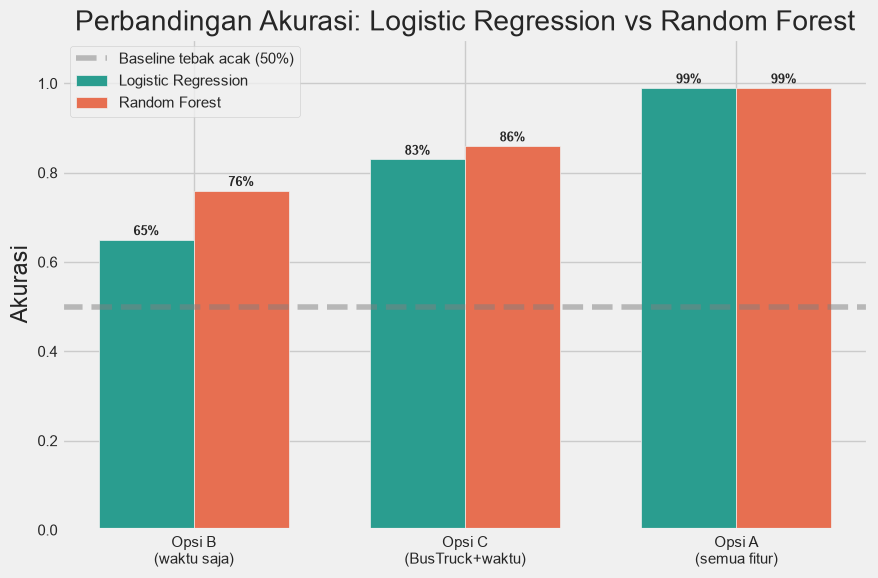

In [60]:
import numpy as np

skenario = ['Opsi B\n(waktu saja)', 'Opsi C\n(BusTruck+waktu)', 'Opsi A\n(semua fitur)']
lr_scores = [0.65, 0.83, 0.99]
rf_scores = [0.76, 0.86, 0.99]

x = np.arange(len(skenario))
width = 0.35

fig, ax = plt.subplots(figsize=(9,6))
bars1 = ax.bar(x - width/2, lr_scores, width, label='Logistic Regression', color='#2a9d8f')
bars2 = ax.bar(x + width/2, rf_scores, width, label='Random Forest', color='#e76f51')

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, height + 0.01, f'{height:.0%}', 
                ha='center', fontweight='bold', fontsize=9)

ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Baseline tebak acak (50%)')
ax.set_ylabel('Akurasi')
ax.set_title('Perbandingan Akurasi: Logistic Regression vs Random Forest')
ax.set_xticks(x)
ax.set_xticklabels(skenario)
ax.set_ylim(0, 1.1)
ax.legend()
plt.tight_layout()
plt.show()

# Cross-Validation

In [61]:
from sklearn.model_selection import cross_val_score

# Cross-validation untuk Opsi A
cv_lr_a = cross_val_score(LogisticRegression(class_weight='balanced', random_state=42), 
                            X_train, y_train, cv=5, scoring='accuracy')
cv_rf_a = cross_val_score(RandomForestClassifier(class_weight='balanced', random_state=42), 
                            X_train, y_train, cv=5, scoring='accuracy')

print("=== Cross-Validation Opsi A (5-fold) ===")
print(f"Logistic Regression: {cv_lr_a.mean():.4f} (+/- {cv_lr_a.std():.4f})")
print(f"Random Forest: {cv_rf_a.mean():.4f} (+/- {cv_rf_a.std():.4f})")

# Cross-validation untuk Opsi B
cv_lr_b = cross_val_score(LogisticRegression(class_weight='balanced', random_state=42), 
                            X_train_b, y_train_b, cv=5, scoring='accuracy')
cv_rf_b = cross_val_score(RandomForestClassifier(class_weight='balanced', random_state=42), 
                            X_train_b, y_train_b, cv=5, scoring='accuracy')

print("\n=== Cross-Validation Opsi B (5-fold) ===")
print(f"Logistic Regression: {cv_lr_b.mean():.4f} (+/- {cv_lr_b.std():.4f})")
print(f"Random Forest: {cv_rf_b.mean():.4f} (+/- {cv_rf_b.std():.4f})")

# Cross-validation untuk Opsi C
cv_lr_c = cross_val_score(LogisticRegression(class_weight='balanced', random_state=42), 
                            X_train_c, y_train_c, cv=5, scoring='accuracy')
cv_rf_c = cross_val_score(RandomForestClassifier(class_weight='balanced', random_state=42), 
                            X_train_c, y_train_c, cv=5, scoring='accuracy')

print("=== Cross-Validation Opsi C (5-fold) ===")
print(f"Logistic Regression: {cv_lr_c.mean():.4f} (+/- {cv_lr_c.std():.4f})")
print(f"Random Forest: {cv_rf_c.mean():.4f} (+/- {cv_rf_c.std():.4f})")

=== Cross-Validation Opsi A (5-fold) ===
Logistic Regression: 0.9873 (+/- 0.0039)
Random Forest: 0.9851 (+/- 0.0014)

=== Cross-Validation Opsi B (5-fold) ===
Logistic Regression: 0.6446 (+/- 0.0040)
Random Forest: 0.7421 (+/- 0.0092)
=== Cross-Validation Opsi C (5-fold) ===
Logistic Regression: 0.8386 (+/- 0.0108)
Random Forest: 0.8692 (+/- 0.0040)


Standar deviasi di semua skenario sangat kecil (0.14% - 1.08%) — ini artinya hasil single split sebelumnya bukan kebetulan, model konsisten menghasilkan performa yang mirip di berbagai kombinasi data train/test. Ini memperkuat kredibilitas seluruh analisis kamu secara statistik.

Pola gap RF vs LR tetap konsisten: makin sedikit fitur volume dominan, makin besar keunggulan Random Forest (Opsi B: gap ~10%, Opsi C: gap ~3%, Opsi A: RF malah sedikit lebih rendah dari LR, tapi bedanya kecil banget/~0.2%).

# Cek untuk model Classification (Random Forest/Logistic Regression)

In [62]:
# cek performa di TRAIN
y_train_pred = model_rf.predict(X_train)
print("=== Performa di TRAIN ===")
print(classification_report(y_train, y_train_pred, target_names=['Lancar', 'Cukup Padat']))

# cek performa di TEST (yang udah kita punya sebelumnya)
print("=== Performa di TEST ===")
print(classification_report(y_test, y_pred_rf, target_names=['Lancar', 'Cukup Padat']))

=== Performa di TRAIN ===
              precision    recall  f1-score   support

      Lancar       1.00      1.00      1.00      3697
 Cukup Padat       1.00      1.00      1.00      3138

    accuracy                           1.00      6835
   macro avg       1.00      1.00      1.00      6835
weighted avg       1.00      1.00      1.00      6835

=== Performa di TEST ===
              precision    recall  f1-score   support

      Lancar       0.99      0.98      0.99       925
 Cukup Padat       0.98      0.99      0.98       784

    accuracy                           0.99      1709
   macro avg       0.99      0.99      0.99      1709
weighted avg       0.99      0.99      0.99      1709



# ROC-AUC Curve

## opsi A

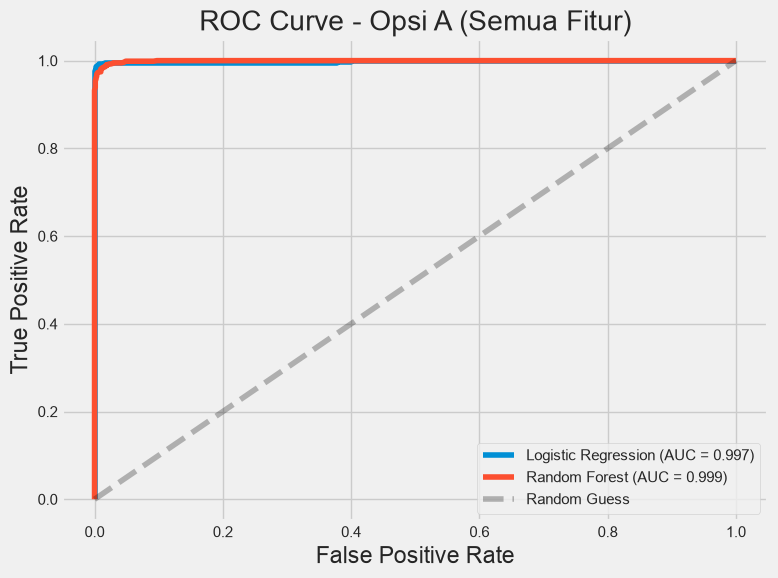

In [63]:
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(8,6))

y_prob_lr = model_lr.predict_proba(X_test)[:, 1]
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
auc_lr = auc(fpr_lr, tpr_lr)

y_prob_rf = model_rf.predict_proba(X_test)[:, 1]
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
auc_rf = auc(fpr_rf, tpr_rf)

plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {auc_lr:.3f})')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.3f})')
plt.plot([0,1], [0,1], 'k--', alpha=0.3, label='Random Guess')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Opsi A (Semua Fitur)')
plt.legend()
plt.tight_layout()
plt.show()

Kurva ROC-nya nunjukin bentuk yang hampir ideal — kedua garis (biru & merah) langsung "nempel" ke sudut kiri atas dengan sangat cepat, jauh dari garis diagonal Random Guess. AUC 0.997 (LR) dan 0.999 (RF) itu mendekati sempurna (AUC = 1.0 berarti klasifikasi sempurna), konsisten banget dengan akurasi 99% yang udah dilihat sebelumnya.

## opsi B

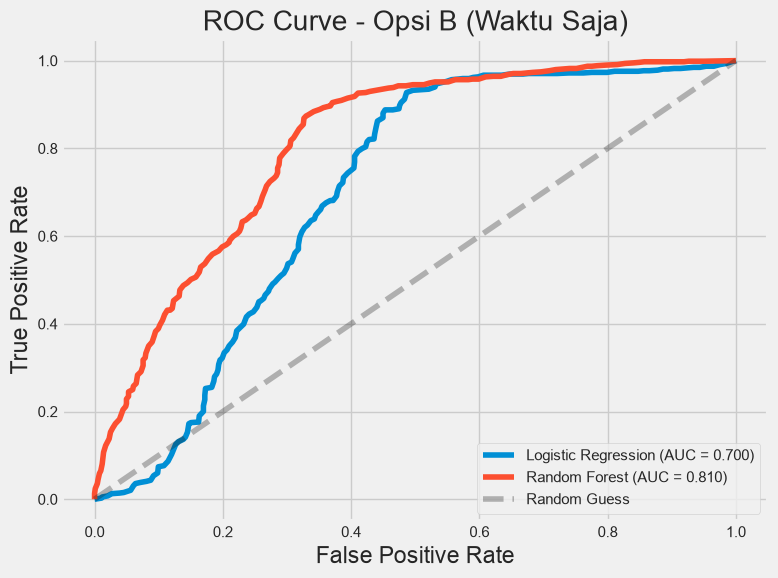

In [64]:
plt.figure(figsize=(8,6))

y_prob_lr_b = model_lr_b.predict_proba(X_test_b)[:, 1]
fpr_lr_b, tpr_lr_b, _ = roc_curve(y_test_b, y_prob_lr_b)
auc_lr_b = auc(fpr_lr_b, tpr_lr_b)

y_prob_rf_b = model_rf_b.predict_proba(X_test_b)[:, 1]
fpr_rf_b, tpr_rf_b, _ = roc_curve(y_test_b, y_prob_rf_b)
auc_rf_b = auc(fpr_rf_b, tpr_rf_b)

plt.plot(fpr_lr_b, tpr_lr_b, label=f'Logistic Regression (AUC = {auc_lr_b:.3f})')
plt.plot(fpr_rf_b, tpr_rf_b, label=f'Random Forest (AUC = {auc_rf_b:.3f})')
plt.plot([0,1], [0,1], 'k--', alpha=0.3, label='Random Guess')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Opsi B (Waktu Saja)')
plt.legend()
plt.tight_layout()
plt.show()

Random Forest (AUC 0.810) konsisten di atas Logistic Regression (AUC 0.700) di hampir sepanjang kurva, bukan cuma di titik akurasi tunggal. Yang menarik, bentuk kurva LR (biru) di area FPR rendah (0.0-0.2) nyaris menempel garis diagonal (Random Guess) — artinya di threshold-threshold tertentu, Logistic Regression hampir gak lebih baik dari tebak acak untuk memisahkan sebagian kasus. Random Forest (merah) jauh lebih baik menjaga jarak dari garis diagonal di area yang sama.

## opsi C

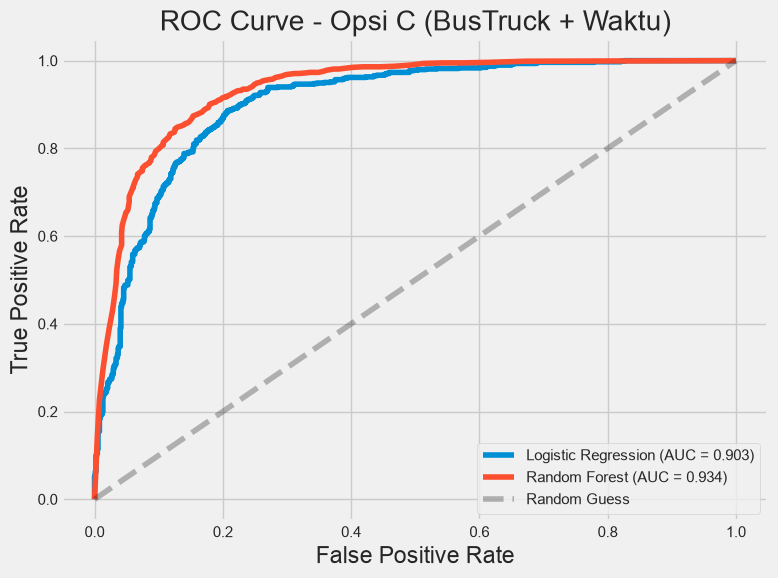

In [65]:
plt.figure(figsize=(8,6))

y_prob_lr_c = model_lr_c.predict_proba(X_test_c)[:, 1]
fpr_lr_c, tpr_lr_c, _ = roc_curve(y_test_c, y_prob_lr_c)
auc_lr_c = auc(fpr_lr_c, tpr_lr_c)

y_prob_rf_c = model_rf_c.predict_proba(X_test_c)[:, 1]
fpr_rf_c, tpr_rf_c, _ = roc_curve(y_test_c, y_prob_rf_c)
auc_rf_c = auc(fpr_rf_c, tpr_rf_c)

plt.plot(fpr_lr_c, tpr_lr_c, label=f'Logistic Regression (AUC = {auc_lr_c:.3f})')
plt.plot(fpr_rf_c, tpr_rf_c, label=f'Random Forest (AUC = {auc_rf_c:.3f})')
plt.plot([0,1], [0,1], 'k--', alpha=0.3, label='Random Guess')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Opsi C (BusTruck + Waktu)')
plt.legend()
plt.tight_layout()
plt.show()

Gap antara Random Forest dan Logistic Regression makin melebar seiring makin sedikitnya fitur volume yang tersedia — sama persis dengan pola yang kamu lihat di accuracy dan cross-validation sebelumnya. Tiga metrik berbeda (accuracy, cross-val, AUC) semuanya mengarah ke kesimpulan yang sama,

# Forecasting

## Step 1 — Buat fitur lag dan rolling statistics

In [66]:
df_ts = df_model.sort_values('Date_and_Time').reset_index(drop=True)

# Lag features — semua valid untuk horizon 1 jam
df_ts['lag_1h'] = df_ts['Total_VCRatio'].shift(1)       # 1 jam lalu
df_ts['lag_24h'] = df_ts['Total_VCRatio'].shift(24)      # 24 jam lalu (hari sebelumnya, jam sama)
df_ts['lag_168h'] = df_ts['Total_VCRatio'].shift(168)    # 168 jam lalu (minggu lalu, hari & jam sama)

# Rolling statistics — shift(1) dulu, biar window cuma lihat data SEBELUM titik yang diprediksi
df_ts['rolling_mean_24h'] = df_ts['Total_VCRatio'].shift(1).rolling(window=24).mean()
df_ts['rolling_mean_7d'] = df_ts['Total_VCRatio'].shift(1).rolling(window=24*7).mean()

# buang baris awal yang belum punya histori lengkap (NaN akibat shift)
df_ts_clean = df_ts.dropna(subset=['lag_1h','lag_24h','lag_168h','rolling_mean_24h','rolling_mean_7d']).reset_index(drop=True)

print(f"Baris sebelum dibuang: {len(df_ts)}")
print(f"Baris setelah dibuang: {len(df_ts_clean)}")

Baris sebelum dibuang: 8544
Baris setelah dibuang: 8376


## Step 2 — Split kronologis (bukan random)

In [67]:
split_date = df_ts_clean['Date_and_Time'].max() - pd.Timedelta(days=60)

train_ts = df_ts_clean[df_ts_clean['Date_and_Time'] <= split_date].copy()
test_ts = df_ts_clean[df_ts_clean['Date_and_Time'] > split_date].copy()

print(f"Train: {train_ts.shape}, {train_ts['Date_and_Time'].min()} s/d {train_ts['Date_and_Time'].max()}")
print(f"Test: {test_ts.shape}, {test_ts['Date_and_Time'].min()} s/d {test_ts['Date_and_Time'].max()}")

Train: (6974, 31), 2023-01-08 04:00:00 s/d 2023-11-01 23:00:00
Test: (1402, 31), 2023-11-02 00:00:00 s/d 2023-12-31 23:00:00


## Step 3 — Encoding fitur kalender

In [68]:
from feature_engine.encoding import OneHotEncoder

ohe_ts = OneHotEncoder(variables=['hari'], drop_last=True)
ohe_ts.fit(train_ts)

train_ts_encoded = ohe_ts.transform(train_ts)
test_ts_encoded = ohe_ts.transform(test_ts)

train_ts_encoded['is_weekend'] = train_ts_encoded['is_weekend'].astype(int)
test_ts_encoded['is_weekend'] = test_ts_encoded['is_weekend'].astype(int)

## Step 4 — Definisikan X dan y

In [69]:
kolom_hari_ts = [col for col in train_ts_encoded.columns if col.startswith('hari_')]

fitur_forecast = ['lag_1h', 'lag_24h', 'lag_168h', 'rolling_mean_24h', 'rolling_mean_7d',
                   'hour', 'is_weekend'] + kolom_hari_ts

X_train_ts = train_ts_encoded[fitur_forecast]
y_train_ts = train_ts_encoded['Total_VCRatio']

X_test_ts = test_ts_encoded[fitur_forecast]
y_test_ts = test_ts_encoded['Total_VCRatio']

print(f"X_train shape: {X_train_ts.shape}")
print(f"X_test shape: {X_test_ts.shape}")

X_train shape: (6974, 13)
X_test shape: (1402, 13)


## Step 5 — Random Forest Regressor

In [70]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

model_rf_ts = RandomForestRegressor(random_state=42, n_estimators=100)
model_rf_ts.fit(X_train_ts, y_train_ts)

y_pred_ts = model_rf_ts.predict(X_test_ts)

mae = mean_absolute_error(y_test_ts, y_pred_ts)
rmse = mean_squared_error(y_test_ts, y_pred_ts) ** 0.5
r2 = r2_score(y_test_ts, y_pred_ts)

print("=== Random Forest (horizon 1 jam, untuk Dishub) ===")
print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")

=== Random Forest (horizon 1 jam, untuk Dishub) ===
MAE  : 0.0160
RMSE : 0.0248
R²   : 0.9172


## Step 6 — Baseline pembanding (naive, pakai lag_1h)

In [71]:
y_pred_naive = X_test_ts['lag_1h']

mae_naive = mean_absolute_error(y_test_ts, y_pred_naive)
rmse_naive = mean_squared_error(y_test_ts, y_pred_naive) ** 0.5
r2_naive = r2_score(y_test_ts, y_pred_naive)

print("\n=== Baseline Naive (lag_1h) ===")
print(f"MAE  : {mae_naive:.4f}")
print(f"RMSE : {rmse_naive:.4f}")
print(f"R²   : {r2_naive:.4f}")


=== Baseline Naive (lag_1h) ===
MAE  : 0.0265
RMSE : 0.0376
R²   : 0.8086


## Feature Importance

In [72]:
importance_ts = pd.DataFrame({
    'fitur': X_train_ts.columns,
    'importance': model_rf_ts.feature_importances_
}).sort_values('importance', ascending=False)

print(importance_ts)

               fitur  importance
0             lag_1h    0.814491
5               hour    0.072353
1            lag_24h    0.035579
3   rolling_mean_24h    0.022258
2           lag_168h    0.021848
4    rolling_mean_7d    0.020851
6         is_weekend    0.003522
12       hari_Friday    0.001824
8        hari_Monday    0.001721
9       hari_Tuesday    0.001417
7        hari_Sunday    0.001405
10    hari_Wednesday    0.001383
11     hari_Thursday    0.001349


Feature importance mengonfirmasi bahwa untuk horizon prediksi jangka pendek 
(1 jam), model sangat bergantung pada nilai VCRatio satu jam sebelumnya 
(kontribusi 81.4%), mencerminkan sifat kondisi lalu lintas yang cenderung 
persisten dalam interval waktu singkat. Fitur kalender seperti hari dan status 
akhir pekan memberikan kontribusi yang relatif kecil pada horizon ini, berbeda 
dengan temuan pada eksperimen horizon 24 jam sebelumnya, di mana pola mingguan 
menjadi jauh lebih relevan karena tidak tersedianya informasi jam-jam terdekat.

## Visualisasi Aktual vs Prediksi (time series plot)

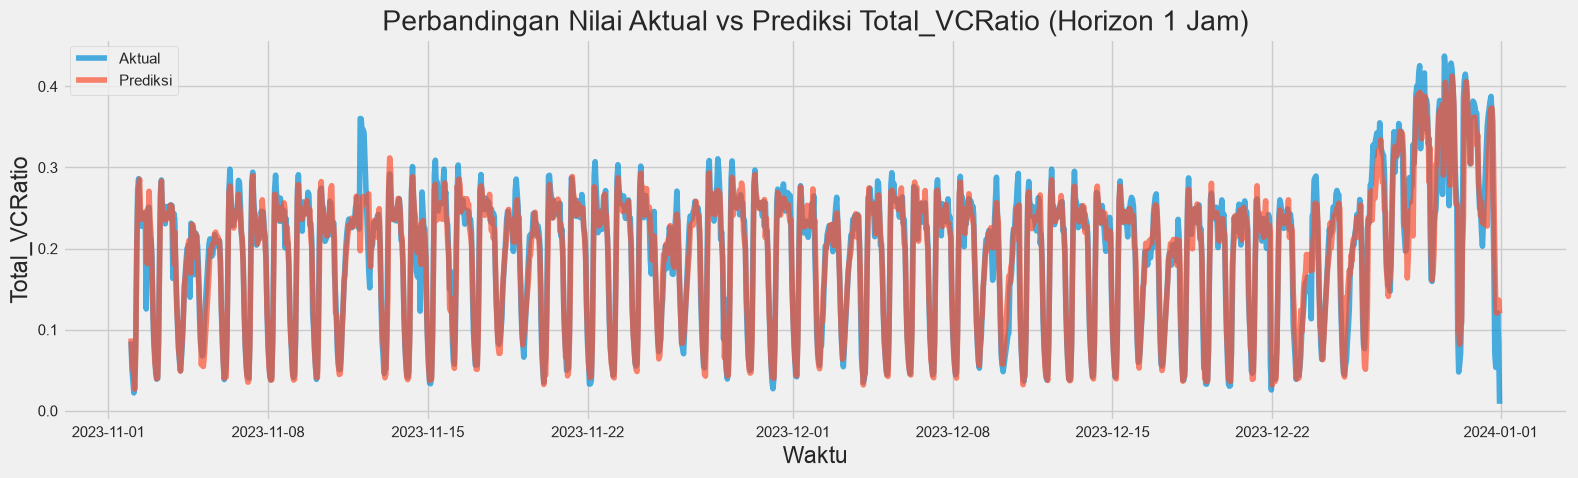

In [73]:
plt.figure(figsize=(16,5))
plt.plot(test_ts['Date_and_Time'].values, y_test_ts.values, label='Aktual', alpha=0.7)
plt.plot(test_ts['Date_and_Time'].values, y_pred_ts, label='Prediksi', alpha=0.7)
plt.title('Perbandingan Nilai Aktual vs Prediksi Total_VCRatio (Horizon 1 Jam)')
plt.xlabel('Waktu')
plt.ylabel('Total_VCRatio')
plt.legend()
plt.tight_layout()
plt.show()

## Zoom in — 1 minggu terakhir (biar detail polanya lebih jelas)

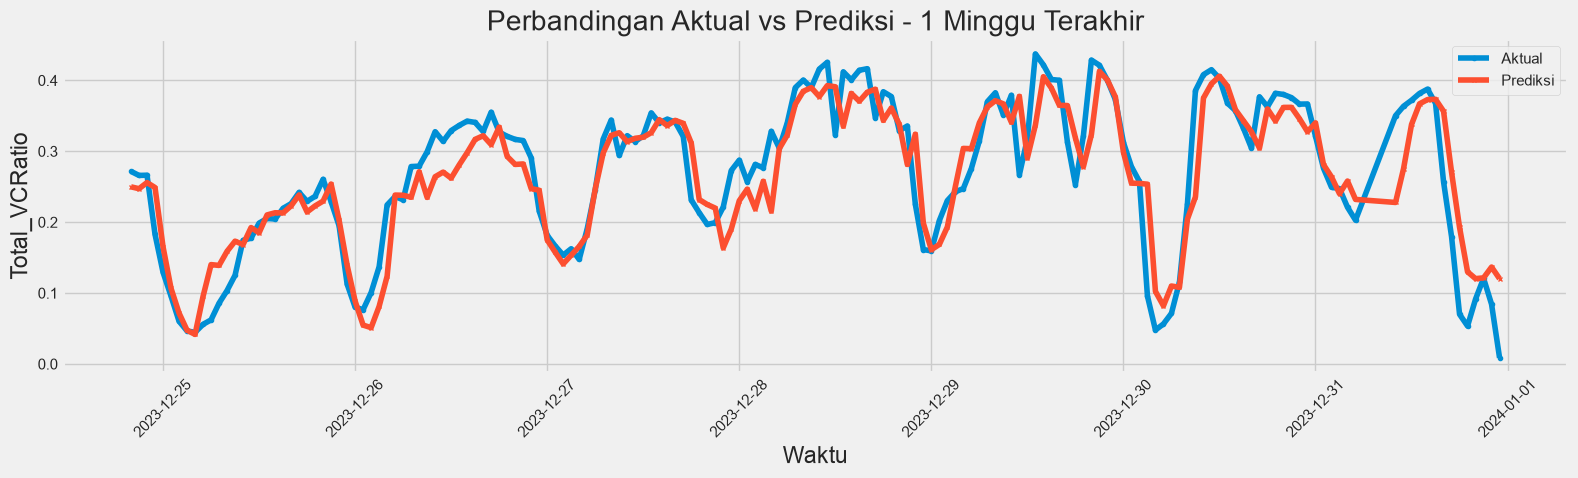

In [74]:
n_zoom = 24*7

plt.figure(figsize=(16,5))
plt.plot(test_ts['Date_and_Time'].values[-n_zoom:], y_test_ts.values[-n_zoom:], label='Aktual', marker='o', markersize=3)
plt.plot(test_ts['Date_and_Time'].values[-n_zoom:], y_pred_ts[-n_zoom:], label='Prediksi', marker='x', markersize=3)
plt.title('Perbandingan Aktual vs Prediksi - 1 Minggu Terakhir')
plt.xlabel('Waktu')
plt.ylabel('Total_VCRatio')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Model forecasting menunjukkan performa yang baik dalam menangkap pola siklus 
harian VCRatio (rush hour pagi-sore). Namun, pada momen malam pergantian tahun 
(31 Desember), model gagal memprediksi penurunan tajam VCRatio yang kemungkinan 
disebabkan oleh kebijakan pengalihan arus lalu lintas khusus. Hal ini 
mengindikasikan bahwa model berbasis lag dan pola waktu belum mampu menangkap 
efek dari event/hari libur khusus, sehingga penambahan fitur kalender event 
(hari libur nasional, malam tahun baru, dll.) dapat menjadi pengembangan 
lanjutan untuk meningkatkan akurasi model di masa depan.

## Cek untuk model Forecasting (Random Forest Regressor)

In [75]:
# performa di TRAIN
y_train_pred_ts = model_rf_ts.predict(X_train_ts)
mae_train = mean_absolute_error(y_train_ts, y_train_pred_ts)
r2_train = r2_score(y_train_ts, y_train_pred_ts)

print("=== Performa di TRAIN ===")
print(f"MAE: {mae_train:.4f}, R²: {r2_train:.4f}")

print("\n=== Performa di TEST ===")
print(f"MAE: {mae:.4f}, R²: {r2:.4f}")

=== Performa di TRAIN ===
MAE: 0.0075, R²: 0.9838

=== Performa di TEST ===
MAE: 0.0160, R²: 0.9172


## Hyperparameter Tuning

In [76]:
from sklearn.ensemble import RandomForestRegressor

model_rf_ts_tuned = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,           # batasi kedalaman pohon (default: unlimited)
    min_samples_leaf=5,     # minimal 5 sampel per daun (default: 1)
    min_samples_split=10,   # minimal 10 sampel buat split (default: 2)
    random_state=42
)
model_rf_ts_tuned.fit(X_train_ts, y_train_ts)

# cek ulang train vs test
y_train_pred_tuned = model_rf_ts_tuned.predict(X_train_ts)
y_test_pred_tuned = model_rf_ts_tuned.predict(X_test_ts)

print("=== Model Tuned - TRAIN ===")
print(f"MAE: {mean_absolute_error(y_train_ts, y_train_pred_tuned):.4f}, R²: {r2_score(y_train_ts, y_train_pred_tuned):.4f}")

print("\n=== Model Tuned - TEST ===")
print(f"MAE: {mean_absolute_error(y_test_ts, y_test_pred_tuned):.4f}, R²: {r2_score(y_test_ts, y_test_pred_tuned):.4f}")

=== Model Tuned - TRAIN ===
MAE: 0.0161, R²: 0.9256

=== Model Tuned - TEST ===
MAE: 0.0161, R²: 0.9181


# Model Disimpan

In [77]:
# Model Simplified — cuma pakai lag_1h + fitur waktu
fitur_forecast_simple = ['lag_1h', 'hour', 'is_weekend'] + kolom_hari_ts

X_train_simple = train_ts_encoded[fitur_forecast_simple]
X_test_simple = test_ts_encoded[fitur_forecast_simple]

model_rf_simple = RandomForestRegressor(random_state=42, n_estimators=100)
model_rf_simple.fit(X_train_simple, y_train_ts)

y_pred_simple = model_rf_simple.predict(X_test_simple)

mae_simple = mean_absolute_error(y_test_ts, y_pred_simple)
r2_simple = r2_score(y_test_ts, y_pred_simple)

print("=== Model Simplified (cuma lag_1h + waktu) ===")
print(f"MAE: {mae_simple:.4f}, R²: {r2_simple:.4f}")

=== Model Simplified (cuma lag_1h + waktu) ===
MAE: 0.0181, R²: 0.9049


In [78]:
import joblib

joblib.dump(model_rf_simple, 'model_forecast_dishub.joblib')
joblib.dump(ohe_ts, 'encoder_hari_dishub.joblib')
joblib.dump(fitur_forecast_simple, 'fitur_forecast_dishub_list.joblib')

print("Model, encoder, dan list fitur berhasil disimpan!")

Model, encoder, dan list fitur berhasil disimpan!


## Cara load ulang nanti (buat dipakai di Gradio)

In [79]:
model_loaded = joblib.load('model_forecast_dishub.joblib')
fitur_loaded = joblib.load('fitur_forecast_dishub_list.joblib')

# ini baris yang kelewat/belum dijalankan
kolom_hari_fitur = [c for c in fitur_loaded if c.startswith('hari_')]

In [80]:
!ls

Traffic.ipynb                     model_forecast_dishub.joblib
encoder_hari.joblib               model_forecast_rf.joblib
encoder_hari_dishub.joblib        traffic_data.csv
fitur_forecast_dishub_list.joblib traffic_data.xlsx
fitur_forecast_list.joblib


# Deployment

## Fungsi prediksi

In [81]:
import gradio as gr
import pandas as pd

def prediksi_vcratio(lag_1h, hour, hari, is_weekend):
    input_df = pd.DataFrame({
        'lag_1h': [lag_1h],
        'hour': [hour],
        'is_weekend': [1 if is_weekend else 0]
    })
    
    for kolom in kolom_hari_fitur:
        nama_hari = kolom.replace('hari_', '')
        input_df[kolom] = 1 if hari == nama_hari else 0
    
    input_final = input_df[fitur_loaded]
    
    prediksi_vc = model_loaded.predict(input_final)[0]
    kategori = "Lancar" if prediksi_vc <= 0.20 else "Cukup Padat"
    
    return kategori, round(prediksi_vc, 4)

demo = gr.Interface(
    fn=prediksi_vcratio,
    inputs=[
        gr.Slider(0, 0.6, value=0.2, step=0.01, label="Kepadatan Lalu Lintas 1 jam lalu"),
        gr.Slider(0, 23, value=8, step=1, label="Jam yang ingin diprediksi"),
        gr.Dropdown(['Senin','Selasa','Rabu','Kamis','Jumat','Sabtu','Minggu'], 
                     value='Senin', label="Hari"),
        gr.Checkbox(label="Akhir Pekan?")
    ],
    outputs=[
        gr.Textbox(label="Tingkat Kepadatan"),
        gr.Number(label="Prediksi Nilai Kepadatan Lalu Lintas")
    ],
    title="Prediksi Kepadatan Lalu Lintas - Dashboard Internal Dishub",
    description="Alat bantu prediksi kepadatan lalu lintas 1 jam ke depan di ruas Jalan Thamrin, cukup masukkan kondisi VCRatio 1 jam terakhir.",
    flagging_mode="never"
)

demo.launch()

* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.
